#Machine Unlearning Notebook

###1. Импорты, конфиг, seed

In [1]:
import os
import gc
import copy
import time
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import roc_auc_score
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Tuple
from tqdm.auto import tqdm
from scipy.stats import entropy
from torch.utils.data import DataLoader, Dataset, Subset, random_split

SEED = 42

def seed_set(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_set()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# resnet18 ~11M | resnet50 ~25M | resnet101 ~44M
MODEL_REGISTRY = {
    "resnet18": ("resnet18", 11.7),
    "resnet50": ("resnet50", 25.6),
    "resnet101": ("resnet101", 44.5),
}

@dataclass
class CFG:
    dataset_name: str = "CIFAR100"
    image_size: int = 32
    batch_size: int = 64
    epochs: int = 30
    lr: float = 1e-3
    weight_decay: float = 5e-4
    num_workers: int = 2
    num_classes: int = 100
    forget_classes: Tuple[int, ...] = (2,)
    val_ratio: float = 0.1
    model_name: str = "resnet18"
    mixed_precision: bool = True
    gradient_clip: float = 1.0
    save_dir: str = "./checkpoints"
    sisa_num_shards: int = 5
    sisa_num_slices: int = 5
    sisa_epochs_per_slice: int = 2

cfg = CFG()

if cfg.model_name not in MODEL_REGISTRY:
    raise ValueError(f"model_name must be one of {list(MODEL_REGISTRY.keys())}")

if cfg.model_name == "resnet101":
    cfg.batch_size = min(cfg.batch_size, 64)

os.makedirs(cfg.save_dir, exist_ok=True)
print(cfg)
print(f"Model: {cfg.model_name}, ~{MODEL_REGISTRY[cfg.model_name][1]}M params")

DEVICE: cuda
CFG(dataset_name='CIFAR100', image_size=32, batch_size=64, epochs=30, lr=0.001, weight_decay=0.0005, num_workers=2, num_classes=100, forget_classes=(2,), val_ratio=0.1, model_name='resnet18', mixed_precision=True, gradient_clip=1.0, save_dir='./checkpoints', sisa_num_shards=5, sisa_num_slices=5, sisa_epochs_per_slice=2)
Model: resnet18, ~11.7M params


###2. Загрузка данных + трансформеров

In [2]:
DATASET_REGISTRY = {
    "CIFAR10": {
        "class": torchvision.datasets.CIFAR10,
        "num_classes": 10,
        "mean": [0.4914, 0.4822, 0.4465],
        "std": [0.2470, 0.2435, 0.2616],
    },
    "CIFAR100": {
        "class": torchvision.datasets.CIFAR100,
        "num_classes": 100,
        "mean": [0.5071, 0.4867, 0.4408],
        "std": [0.2675, 0.2565, 0.2761],
    },
}

if cfg.dataset_name not in DATASET_REGISTRY:
    raise ValueError(
        f"Unknown dataset: {cfg.dataset_name}. "
        f"Choose from: {list(DATASET_REGISTRY.keys())}"
    )

ds_info = DATASET_REGISTRY[cfg.dataset_name]

if cfg.num_classes != ds_info["num_classes"]:
    raise ValueError(
        f"cfg.num_classes={cfg.num_classes}, но для {cfg.dataset_name} "
        f"нужно num_classes={ds_info['num_classes']}. "
    )

DatasetClass = ds_info["class"]

normalize = T.Normalize(
    mean=ds_info["mean"],
    std=ds_info["std"]
)

train_transform = T.Compose([
    T.RandomCrop(cfg.image_size, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    normalize
])

valid_transform = T.Compose([
    T.ToTensor(),
    normalize
])

train_dataset_full = DatasetClass(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = DatasetClass(
    root="./data",
    train=False,
    download=True,
    transform=valid_transform
)

class_names = train_dataset_full.classes
train_dataset = train_dataset_full

# проверка меток
_targets = np.array(train_dataset_full.targets)
assert _targets.min() >= 0
assert _targets.max() < cfg.num_classes, (
    f"Метка {_targets.max()} >= num_classes={cfg.num_classes}"
)

print(f"Dataset: {cfg.dataset_name}")
print(f"Classes: {cfg.num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Example labels: min={_targets.min()}, max={_targets.max()}")

Dataset: CIFAR100
Classes: 100
Train samples: 50000
Test samples: 10000
Example labels: min=0, max=99


###3. Разделение детесета на тестовую и обучающую выборки. И разделение обучающей выборки на Retain и Forget

In [3]:
val_size = int(len(train_dataset) * cfg.val_ratio)

train_size = len(train_dataset) - val_size


train_dataset, valid_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)


train_targets = np.array([
    train_dataset.dataset.targets[idx] for idx in train_dataset.indices
])


forget_mask = np.isin(
    train_targets,
    cfg.forget_classes
)

retain_mask = ~forget_mask


forget_indices = np.where(forget_mask)[0]
retain_indices = np.where(retain_mask)[0]


forget_dataset = Subset(train_dataset, forget_indices)

retain_dataset = Subset(train_dataset, retain_indices)


print("Forget classes:", cfg.forget_classes)
print("Forget samples:", len(forget_dataset))
print("Retain samples:", len(retain_dataset))


train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

forget_loader = DataLoader(
    forget_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

retain_loader = DataLoader(
    retain_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

Forget classes: (2,)
Forget samples: 454
Retain samples: 44546


###4. Визуализация изображений из датасета

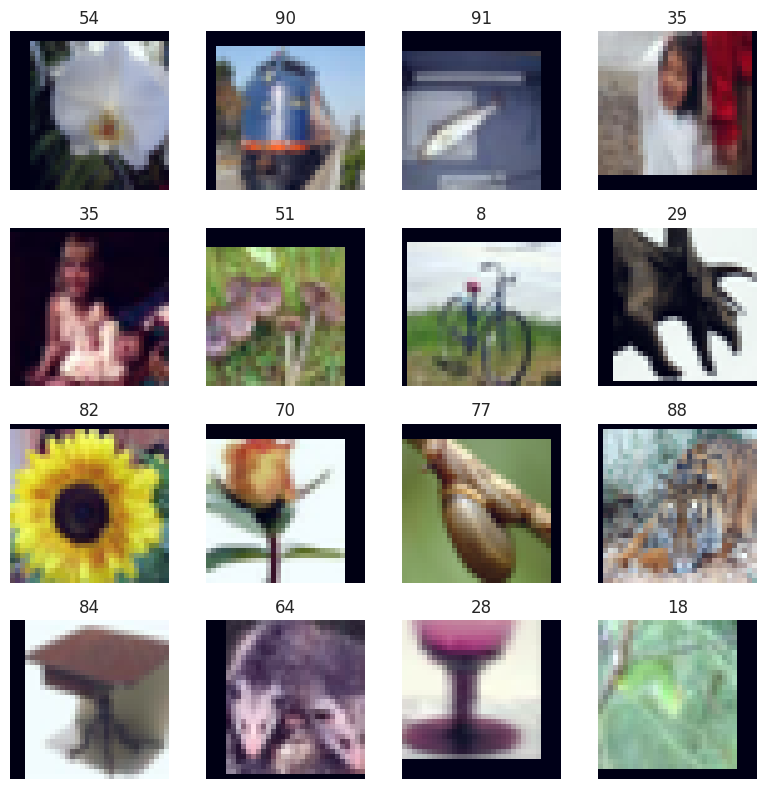

In [4]:
def show_batch(loader, n=16):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))

    for img, label, ax in zip(images,labels,axes.flatten()):
        img = img.permute(1, 2, 0).numpy()

        img = (img - img.min()) / (img.max() - img.min())

        ax.imshow(img)
        ax.set_title(int(label))
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_loader)

###5. Создание моделей

Создаются моделей ResNet18, ResNet50 и ResNet101

In [5]:
def build_model(model_name=None):
    model_name = model_name or cfg.model_name
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {model_name}")

    ctor_name, _ = MODEL_REGISTRY[model_name]
    ctor = getattr(models, ctor_name)
    model = ctor(weights=None)
    model.fc = nn.Linear(model.fc.in_features, cfg.num_classes)
    return model.to(DEVICE)

def count_params_m(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

model = build_model()
print(type(model).__name__, f"{count_params_m(model):.1f}M params")

ResNet 11.2M params


###6. Обучение + Оценка качества

Считается Accuracy, дивергенция Кульбака-Лейблера, Truth Ratio

In [6]:
class SISAShard:
    def __init__(self, shard_id, slice_checkpoints, slice_index_lists):
        self.shard_id = shard_id
        self.slice_checkpoints = slice_checkpoints
        self.slice_index_lists = slice_index_lists

class SISAEnsemble(nn.Module):
    """Предсказание по shard по очереди — не держим все модели на GPU."""
    def __init__(self, shard_objects, model_name=None):
        super().__init__()
        self.shard_objects = shard_objects
        self.model_name = model_name or cfg.model_name

    def forward(self, x):
        probs_sum = None
        for shard in self.shard_objects:
            m = build_model(self.model_name)
            m.load_state_dict(shard.slice_checkpoints[-1])
            m.to(x.device)
            m.eval()
            with torch.no_grad():
                p = torch.softmax(m(x), dim=1)
            probs_sum = p if probs_sum is None else probs_sum + p
            del m
        return probs_sum / len(self.shard_objects)

criterion = nn.CrossEntropyLoss()

def accuracy_from_probs(probs, labels):
    return (probs.argmax(dim=1) == labels).float().mean().item()

def accuracy(logits, labels):
    if logits.dim() == 2 and logits.size(1) == cfg.num_classes:
        return accuracy_from_probs(torch.softmax(logits, dim=1), labels)
    return accuracy_from_probs(logits, labels)

def _forward_probs(model, images):
    out = model(images)
    return out if isinstance(model, SISAEnsemble) else torch.softmax(out, dim=1)

def compute_truth_ratio(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            probs = _forward_probs(model, images)
            scores.extend(probs[torch.arange(labels.size(0)), labels].cpu().numpy())
    return float(np.mean(scores))

def evaluate(model, loader):
    model.eval()
    losses, accs = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out = model(images)
            if isinstance(model, SISAEnsemble):
                probs = out
                loss = F.nll_loss(torch.log(probs + 1e-12), labels)
            else:
                probs = torch.softmax(out, dim=1)
                loss = criterion(out, labels)
            accs.append(accuracy_from_probs(probs, labels))
            losses.append(loss.item())
    return {"loss": np.mean(losses), "accuracy": np.mean(accs)}

###7. Общие функции для забывания
Копирование модели, время работы, обучение модели на методе забывания

In [7]:
MODEL_CPU = {}

def gpu_mem_gb():
    return torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0

def cuda_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def _stash_path(name):
    safe = name.replace(" + ", "_").replace(" ", "_")
    return os.path.join(cfg.save_dir, f"stash_{safe}.pt")

def stash_model(name, m):
    path = _stash_path(name)
    torch.save(m.cpu().state_dict(), path)
    MODEL_CPU[name] = path
    cuda_cleanup()
    return path

def stash_sisa(name, ensemble, shard_objects):
    path = os.path.join(cfg.save_dir, "sisa_bundle.pt")
    torch.save(
        {
            "model_name": cfg.model_name,
            "shard_objects": shard_objects,
        },
        path,
    )
    MODEL_CPU[name] = path
    cuda_cleanup()
    return path


def load_model_from_stash(name):
    if name not in MODEL_CPU:
        raise KeyError(f"Нет '{name}' в MODEL_CPU")

    path = MODEL_CPU[name]

    if name == "SISA":
        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        return SISAEnsemble(
            data["shard_objects"],
            model_name=data.get("model_name", cfg.model_name)
        )

    # обычные модели
    state_dict = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    m = build_model()
    m.load_state_dict(state_dict, strict=True)

    return m


def clone_model_from_base():
    m = build_model()
    m.load_state_dict(torch.load(MODEL_CPU["Base"], map_location="cpu"))
    return m.to(DEVICE)

def start_timer():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.time()

def end_timer(t0):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.time() - t0

def reset_classifier(model):
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, cfg.num_classes).to(DEVICE)
    return model.fc.parameters()

def evaluate_unlearning_method(model, method_name, runtime_seconds, shard_objects=None):
    model = model.to(DEVICE)
    retain_metrics = evaluate(model, retain_loader)
    forget_metrics = evaluate(model, forget_loader)
    test_metrics = evaluate(model, test_loader)

    result = {
        "Method": method_name,

        "Retain Acc": retain_metrics["accuracy"],
        "Forget Acc": forget_metrics["accuracy"],
        "Test Acc": test_metrics["accuracy"],

        "Retain Loss": retain_metrics["loss"],
        "Forget Loss": forget_metrics["loss"],
        "Test Loss": test_metrics["loss"],

        "Runtime": runtime_seconds,
    }
    all_results.append(result)

    if isinstance(model, SISAEnsemble):
        if shard_objects is None:
            raise ValueError("Для SISA передайте shard_objects в evaluate_unlearning_method")
        stash_sisa(method_name, model, shard_objects)
    else:
        stash_model(method_name, model)

    return result

###8. Полное обучение

Обучается базовая модель и сохраняется лучший чекпоинт

In [8]:
_sample_labels = np.array(train_dataset_full.targets)

assert _sample_labels.max() < cfg.num_classes, (
    f"Метка {_sample_labels.max()} >= num_classes={cfg.num_classes}. "
    "Для CIFAR-100 установите num_classes=100."
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs
)

scaler = torch.cuda.amp.GradScaler(
    enabled=cfg.mixed_precision
)

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_acc = 0.0

best_path = os.path.join(
    cfg.save_dir,
    f"best_{cfg.model_name}.pt"
)

for epoch in range(cfg.epochs):

    model.train()

    train_losses = []
    train_accs = []

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{cfg.epochs}"
    )

    for images, labels in progress:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(
            enabled=cfg.mixed_precision
        ):

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

        if torch.isnan(loss):
            continue

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            cfg.gradient_clip
        )

        scaler.step(optimizer)

        scaler.update()

        acc = accuracy(logits, labels)

        train_losses.append(loss.item())

        train_accs.append(acc)

        progress.set_description(
            f"loss={loss.item():.4f} "
            f"acc={acc:.4f}"
        )

    scheduler.step()

    valid_metrics = evaluate(
        model,
        valid_loader
    )

    history["train_loss"].append(
        np.mean(train_losses)
    )

    history["train_acc"].append(
        np.mean(train_accs)
    )

    history["valid_loss"].append(
        valid_metrics["loss"]
    )

    history["valid_acc"].append(
        valid_metrics["accuracy"]
    )

    print(
        f"Epoch={epoch+1} | "
        f"TrainLoss={np.mean(train_losses):.4f} | "
        f"TrainAcc={np.mean(train_accs):.4f} | "
        f"ValidLoss={valid_metrics['loss']:.4f} | "
        f"ValidAcc={valid_metrics['accuracy']:.4f}"
    )

    if valid_metrics["accuracy"] > best_acc:

        best_acc = valid_metrics["accuracy"]

        torch.save(
            model.state_dict(),
            best_path
        )

        print("Лучшие параметры сохранены")


model.load_state_dict(
    torch.load(
        best_path,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

stash_model("Base", model)

print("\nBase model saved successfully")

Epoch 1/30:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch=1 | TrainLoss=3.8502 | TrainAcc=0.1086 | ValidLoss=3.5545 | ValidAcc=0.1602
Лучшие параметры сохранены


Epoch 2/30:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch=2 | TrainLoss=3.2542 | TrainAcc=0.2042 | ValidLoss=3.0305 | ValidAcc=0.2474
Лучшие параметры сохранены


Epoch 3/30:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch=28 | TrainLoss=0.6218 | TrainAcc=0.8126 | ValidLoss=2.0786 | ValidAcc=0.5174
Лучшие параметры сохранены


Epoch 29/30:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch=29 | TrainLoss=0.6128 | TrainAcc=0.8159 | ValidLoss=2.0777 | ValidAcc=0.5190
Лучшие параметры сохранены


Epoch 30/30:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch=30 | TrainLoss=0.6044 | TrainAcc=0.8193 | ValidLoss=2.0662 | ValidAcc=0.5222
Лучшие параметры сохранены

Base model saved successfully


###9. Оценка базовой модели

Берутся лучшие переметры, модель оценивается и считаются метрики

In [9]:
model.load_state_dict(
    torch.load(
        os.path.join(cfg.save_dir, f"best_{cfg.model_name}.pt"),
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

train_metrics = evaluate(model, train_loader)
valid_metrics = evaluate(model, valid_loader)
retain_metrics = evaluate(model, retain_loader)
forget_metrics = evaluate(model, forget_loader)
test_metrics = evaluate(model, test_loader)

baseline_row = {
    "Method": "Base",
    "Retain Acc": retain_metrics["accuracy"],
    "Forget Acc": forget_metrics["accuracy"],
    "Test Acc": test_metrics["accuracy"],
    "Retain Loss": retain_metrics["loss"],
    "Forget Loss": forget_metrics["loss"],
    "Test Loss": test_metrics["loss"],
    "Valid Loss": valid_metrics["loss"],
    "Runtime": np.nan,
}

baseline_results = pd.DataFrame([baseline_row])
all_results = [baseline_row]

baseline_results

,Method,Retain Acc,Forget Acc,Test Acc,Retain Loss,Forget Loss,Test Loss,Valid Loss,Runtime
0,Base,0.856393,0.786458,0.538117,0.491639,0.769764,2.063164,2.071527,NaN


###10. Тренировочные кривые

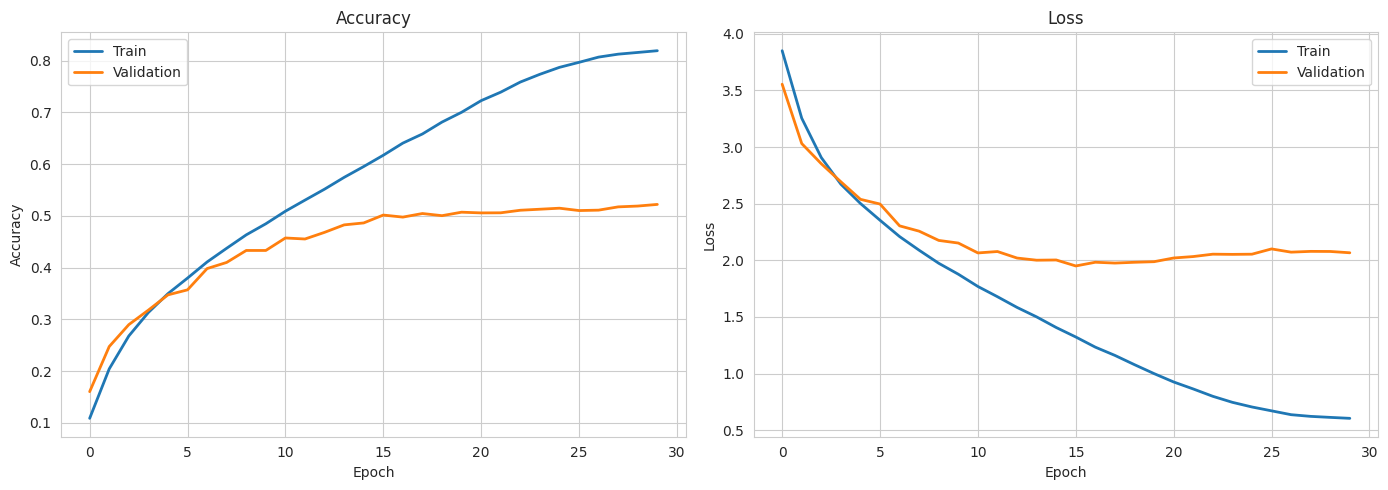

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history["train_acc"],
    label="Train",
    linewidth=2
)

axes[0].plot(
    history["valid_acc"],
    label="Validation",
    linewidth=2
)

axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(
    history["train_loss"],
    label="Train",
    linewidth=2
)

axes[1].plot(
    history["valid_loss"],
    label="Validation",
    linewidth=2
)

axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()

plt.show()

###11. Retrain модель

In [11]:
retain_train_loader = DataLoader(
    retain_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

def retrain_baseline():
    start_time = start_timer()
    retrain_model = build_model()

    optimizer = optim.AdamW(
        retrain_model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.mixed_precision)

    best_acc = 0.0
    ckpt_path = os.path.join(cfg.save_dir, "retraining_baseline.pt")

    for epoch in range(cfg.epochs):
        retrain_model.train()
        for images, labels in tqdm(retain_train_loader, desc=f"Retrain {epoch+1}/{cfg.epochs}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=cfg.mixed_precision):
                loss = criterion(retrain_model(images), labels)

            if not torch.isfinite(loss):
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(retrain_model.parameters(), cfg.gradient_clip)
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()
        valid_metrics = evaluate(retrain_model, valid_loader)
        print(f"Epoch={epoch+1} ValidAcc={valid_metrics['accuracy']:.4f}")

        if valid_metrics["accuracy"] > best_acc:
            best_acc = valid_metrics["accuracy"]
            torch.save(retrain_model.state_dict(), ckpt_path)

    retrain_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return retrain_model, end_timer(start_time)

cuda_cleanup()
retrain_model, retrain_runtime = retrain_baseline()

retrain_results = evaluate_unlearning_method(
    retrain_model,
    "Retrain",
    retrain_runtime,
)
del retrain_model
cuda_cleanup()
pd.DataFrame([retrain_results])

Retrain 1/30:   0%|          | 0/697 [00:00<?, ?it/s]

Epoch=1 ValidAcc=0.1521


Retrain 2/30:   0%|          | 0/697 [00:00<?, ?it/s]

Epoch=2 ValidAcc=0.2298


Retrain 3/30:   0%|          | 0/697 [00:00<?, ?it/s]

...

Retrain 29/30:   0%|          | 0/697 [00:00<?, ?it/s]

Epoch=29 ValidAcc=0.5020


Retrain 30/30:   0%|          | 0/697 [00:00<?, ?it/s]

Epoch=30 ValidAcc=0.5002


,Method,Retain Acc,Forget Acc,Test Acc,Retain Loss,Forget Loss,Test Loss,Runtime
0,Retrain,0.762711,0.0,0.522791,0.783469,28.177471,2.24714,963.09812


###12. Градиентный подъем (Gradient Ascent)

In [12]:
def gradient_ascent_unlearning(steps=5, ga_lr=5e-6):
    t0 = start_timer()
    m = clone_model_from_base()
    opt = optim.SGD(m.parameters(), lr=ga_lr, momentum=0.9)

    for step in range(steps):
        m.train()
        for images, labels in tqdm(forget_loader, desc=f"GA {step+1}/{steps}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = -criterion(m(images), labels)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), cfg.gradient_clip)
            opt.step()
        print(f"step {step+1}: retain={evaluate(m, retain_loader)['accuracy']:.3f}, forget={evaluate(m, forget_loader)['accuracy']:.3f}")

    return m, end_timer(t0)

cuda_cleanup()
m_ga, t_ga = gradient_ascent_unlearning()
evaluate_unlearning_method(m_ga, "Gradient Ascent", t_ga)
del m_ga
cuda_cleanup()

GA 1/5:   0%|          | 0/8 [00:00<?, ?it/s]

step 1: retain=0.744, forget=0.172


GA 2/5:   0%|          | 0/8 [00:00<?, ?it/s]

step 2: retain=0.616, forget=0.066


GA 3/5:   0%|          | 0/8 [00:00<?, ?it/s]

step 3: retain=0.556, forget=0.031


GA 4/5:   0%|          | 0/8 [00:00<?, ?it/s]

step 4: retain=0.541, forget=0.012


GA 5/5:   0%|          | 0/8 [00:00<?, ?it/s]

step 5: retain=0.526, forget=0.016


###13. Метод Случайных меток (Random Labels)

In [13]:
class RandomLabelDataset(Dataset):
    def __init__(self, subset, num_classes):
        self.dataset = subset
        self.num_classes = num_classes

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        rnd = random.randint(0, self.num_classes - 1)
        while rnd == label:
            rnd = random.randint(0, self.num_classes - 1)
        return image, rnd

def random_label_unlearning(epochs=3, rl_lr=1e-5):
    t0 = start_timer()
    m = clone_model_from_base()
    loader = DataLoader(
        RandomLabelDataset(forget_dataset, cfg.num_classes),
        batch_size=cfg.batch_size, shuffle=True, num_workers=0,
    )
    opt = optim.AdamW(m.parameters(), lr=rl_lr)
    for epoch in range(epochs):
        m.train()
        for images, labels in tqdm(loader, desc=f"RL {epoch+1}/{epochs}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(m(images), labels)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            opt.step()
    return m, end_timer(t0)

cuda_cleanup()
m_rl, t_rl = random_label_unlearning()
evaluate_unlearning_method(m_rl, "Random Labels", t_rl)
del m_rl
cuda_cleanup()

RL 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

RL 2/3:   0%|          | 0/8 [00:00<?, ?it/s]

RL 3/3:   0%|          | 0/8 [00:00<?, ?it/s]

###14. Метод добавления шума Фишера (Fisher Noise)

In [14]:
def estimate_fisher(model, loader, max_batches=50, eps=1e-4):
    model.train()
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    n_batches = 0
    for i, (images, labels) in enumerate(loader):
        if i >= max_batches:
            break
        n_batches += 1
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        model.zero_grad(set_to_none=True)
        criterion(model(images), labels).backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.detach().pow(2)
    for n in fisher:
        fisher[n] /= max(n_batches, 1)
        fisher[n].clamp_(min=eps)
    return fisher

def fisher_noise_unlearning(noise_scale=0.01, max_noise_ratio=0.08, finetune_epochs=3, finetune_lr=3e-4):
    t0 = start_timer()
    m = clone_model_from_base()
    fisher = estimate_fisher(m, retain_loader)

    with torch.no_grad():
        for n, p in m.named_parameters():
            sigma = noise_scale / torch.sqrt(fisher[n])
            sigma = torch.clamp(sigma, max=max_noise_ratio * p.abs().clamp(min=1e-6))
            p.add_(torch.randn_like(p) * sigma)
    del fisher

    if finetune_epochs > 0:
        opt = optim.AdamW(m.parameters(), lr=finetune_lr, weight_decay=cfg.weight_decay)
        for epoch in range(finetune_epochs):
            m.train()
            for images, labels in tqdm(retain_loader, desc=f"Fisher FT {epoch+1}"):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                loss = criterion(m(images), labels)
                if not torch.isfinite(loss):
                    continue
                loss.backward()
                opt.step()
    return m, end_timer(t0)

cuda_cleanup()
m_f, t_f = fisher_noise_unlearning()
evaluate_unlearning_method(m_f, "Fisher Noise", t_f)
del m_f
cuda_cleanup()

Fisher FT 1:   0%|          | 0/697 [00:00<?, ?it/s]

Fisher FT 2:   0%|          | 0/697 [00:00<?, ?it/s]

Fisher FT 3:   0%|          | 0/697 [00:00<?, ?it/s]

###15. Метод сброса последнего слоя (Reset Last Layer)

In [15]:
def reset_last_layer_unlearning(finetune_epochs=5, lr=1e-3):
    t0 = start_timer()
    m = clone_model_from_base()

    for p in m.parameters():
        p.requires_grad = False

    opt = optim.AdamW(reset_classifier(m), lr=lr)

    for epoch in range(finetune_epochs):
        m.train()
        for images, labels in tqdm(retain_loader, desc=f"Reset {epoch+1}/{finetune_epochs}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(m(images), labels)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            opt.step()

    return m, end_timer(t0)

cuda_cleanup()
m_reset, t_reset = reset_last_layer_unlearning()
evaluate_unlearning_method(m_reset, "Reset Last Layer", t_reset)
del m_reset
cuda_cleanup()

Reset 1/5:   0%|          | 0/697 [00:00<?, ?it/s]

Reset 2/5:   0%|          | 0/697 [00:00<?, ?it/s]

Reset 3/5:   0%|          | 0/697 [00:00<?, ?it/s]

Reset 4/5:   0%|          | 0/697 [00:00<?, ?it/s]

Reset 5/5:   0%|          | 0/697 [00:00<?, ?it/s]

###16. Метод SISA

In [16]:
def create_sisa_partitions(n_samples, num_shards, num_slices, seed=SEED):
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n_samples)
    shards = np.array_split(indices, num_shards)
    return [list(np.array_split(s, num_slices)) for s in shards]


def train_single_slice(model, subset, epochs):
    loader = DataLoader(
        subset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True
    )
    opt = optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )
    for _ in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(model(images), labels)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                cfg.gradient_clip
            )
            opt.step()
    return model


def train_shard_from_scratch(train_ds, slice_index_lists, epochs_per_slice):
    model = build_model()
    checkpoints, cumulative = [], []
    for slice_id, slice_idx in enumerate(slice_index_lists):
        cumulative.extend(slice_idx.tolist())
        model = train_single_slice(model, Subset(train_ds, cumulative), epochs_per_slice)
        checkpoints.append(copy.deepcopy(model.state_dict()))
        print(f"  slice {slice_id+1}, n={len(cumulative)}")
    del model
    cuda_cleanup()
    return checkpoints


def first_affected_slice(slice_index_lists, forget_idx):
    fset = set(forget_idx.tolist())
    for k, sl in enumerate(slice_index_lists):
        if any(int(i) in fset for i in sl):
            return k
    return None


def unlearn_shard(train_ds, slice_index_lists, checkpoints, forget_idx, epochs_per_slice):
    fset = set(forget_idx.tolist())
    k = first_affected_slice(slice_index_lists, forget_idx)
    if k is None:
        return checkpoints

    model = build_model()
    if k > 0:
        model.load_state_dict(checkpoints[k - 1])
        new_ckpt = checkpoints[:k]
    else:
        new_ckpt = []

    for t in range(k, len(slice_index_lists)):
        cumulative = []
        for s in range(t + 1):
            cumulative.extend(int(i) for i in slice_index_lists[s] if int(i) not in fset)
        cumulative = list(dict.fromkeys(cumulative))
        if not cumulative:
            continue
        model = train_single_slice(model, Subset(train_ds, cumulative), epochs_per_slice)
        new_ckpt.append(copy.deepcopy(model.state_dict()))
    del model
    cuda_cleanup()
    return new_ckpt


def build_sisa_system(train_ds, forget_global_indices=None):
    shard_slices = create_sisa_partitions(len(train_ds), cfg.sisa_num_shards, cfg.sisa_num_slices)
    shard_objects = []
    for sid, slices in enumerate(shard_slices):
        print(f"Shard {sid+1}/{cfg.sisa_num_shards}")
        ckpt = train_shard_from_scratch(train_ds, slices, cfg.sisa_epochs_per_slice)
        shard_objects.append(SISAShard(sid, ckpt, slices))
    return SISAEnsemble(shard_objects), shard_objects

def sisa_unlearning(train_ds, shard_objects, forget_global_indices):
    t0 = start_timer()
    new_shards = []
    forget_global_indices = np.asarray(forget_global_indices, dtype=int)
    for shard in shard_objects:
        f_in = np.array([i for sl in shard.slice_index_lists for i in sl if int(i) in set(forget_global_indices)])
        if len(f_in) == 0:
            ckpt = shard.slice_checkpoints
        else:
            ckpt = unlearn_shard(train_ds, shard.slice_index_lists, shard.slice_checkpoints, f_in, cfg.sisa_epochs_per_slice)
        new_shards.append(SISAShard(shard.shard_id, ckpt, shard.slice_index_lists))
    return SISAEnsemble(new_shards), new_shards, end_timer(t0)

cuda_cleanup()
sisa_model, sisa_shards = build_sisa_system(train_dataset)
sisa_model, sisa_shards, t_sisa = sisa_unlearning(train_dataset, sisa_shards, forget_indices)

evaluate_unlearning_method(sisa_model, "SISA", t_sisa, shard_objects=sisa_shards)

del sisa_model
cuda_cleanup()

Shard 1/5
  slice 1, n=1800
  slice 2, n=3600
  slice 3, n=5400
  slice 4, n=7200
  slice 5, n=9000
Shard 2/5
  slice 1, n=1800
  slice 2, n=3600
  slice 3, n=5400
  slice 4, n=7200
  slice 5, n=9000
Shard 3/5
  slice 1, n=1800
  slice 2, n=3600
  slice 3, n=5400
  slice 4, n=7200
  slice 5, n=9000
Shard 4/5
  slice 1, n=1800
  slice 2, n=3600
  slice 3, n=5400
  slice 4, n=7200
  slice 5, n=9000
Shard 5/5
  slice 1, n=1800
  slice 2, n=3600
  slice 3, n=5400
  slice 4, n=7200
  slice 5, n=9000


###17. Комбинированные методы

Реализованы комбинации:
1) Random Labels + Gradient Ascent
2) Reset Last Layer + Gradient Ascent
3) Reset Last Layer + Random Labels

In [17]:
HP = dict(rl_epochs=3, rl_lr=5e-5, ga_steps=3, ga_lr=8e-6, reset_epochs=3, reset_rl_epochs=3, reset_rl_lr=8e-5)


def _rl_phase(m, epochs, lr, desc="RL"):
    loader = DataLoader(RandomLabelDataset(forget_dataset, cfg.num_classes),
                        batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    opt = optim.AdamW(m.parameters(), lr=lr)
    for ep in range(epochs):
        m.train()
        for img, lab in tqdm(loader, desc=f"{desc} {ep+1}", leave=False):
            img, lab = img.to(DEVICE), lab.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(m(img), lab)
            if torch.isfinite(loss):
                loss.backward()
                opt.step()
    return m


def _ga_phase(m, steps, lr, desc="GA"):
    opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    for step in range(steps):
        m.train()
        for img, lab in tqdm(forget_loader, desc=f"{desc} {step+1}", leave=False):
            img, lab = img.to(DEVICE), lab.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = -criterion(m(img), lab)
            if torch.isfinite(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), cfg.gradient_clip)
                opt.step()
    return m


def _reset_phase(m, epochs, lr=1e-3):
    for p in m.parameters():
        p.requires_grad = False
    opt = optim.AdamW(reset_classifier(m), lr=lr)
    for ep in range(epochs):
        m.train()
        for img, lab in tqdm(retain_loader, desc=f"Reset {ep+1}", leave=False):
            img, lab = img.to(DEVICE), lab.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(m(img), lab)
            if torch.isfinite(loss):
                loss.backward()
                opt.step()
    return m


def _run_hybrid(name, train_fn):
    print(f"{name}")
    cuda_cleanup()
    m, rt = train_fn()
    evaluate_unlearning_method(m, name, rt)
    del m
    cuda_cleanup()


def _hybrid_rl_ga():
    t0 = start_timer()
    m = clone_model_from_base()
    m = _rl_phase(m, HP["rl_epochs"], HP["rl_lr"], "RL+GA")
    return _ga_phase(m, HP["ga_steps"], HP["ga_lr"], "RL+GA"), end_timer(t0)


def _hybrid_reset_ga():
    t0 = start_timer()
    m = clone_model_from_base()
    m = _reset_phase(m, HP["reset_epochs"])
    for p in m.parameters():
        p.requires_grad = True
    m = _ga_phase(m, HP["ga_steps"], HP["ga_lr"], "Reset+GA")
    return m, end_timer(t0)


def _hybrid_reset_rl():
    t0 = start_timer()
    m = clone_model_from_base()
    m = _reset_phase(m, HP["reset_epochs"])
    for p in m.parameters():
        p.requires_grad = True
    m = _rl_phase(m, HP["reset_rl_epochs"], HP["reset_rl_lr"], "Reset+RL")
    return m, end_timer(t0)

_run_hybrid("RL + GA", _hybrid_rl_ga)
_run_hybrid("Reset + GA", _hybrid_reset_ga)
_run_hybrid("Reset + RL", _hybrid_reset_rl)

RL + GA


RL+GA 1:   0%|          | 0/8 [00:00<?, ?it/s]

RL+GA 2:   0%|          | 0/8 [00:00<?, ?it/s]

RL+GA 3:   0%|          | 0/8 [00:00<?, ?it/s]

RL+GA 1:   0%|          | 0/8 [00:00<?, ?it/s]

...

Reset 2:   0%|          | 0/697 [00:00<?, ?it/s]

Reset 3:   0%|          | 0/697 [00:00<?, ?it/s]

Reset+RL 1:   0%|          | 0/8 [00:00<?, ?it/s]

Reset+RL 2:   0%|          | 0/8 [00:00<?, ?it/s]

Reset+RL 3:   0%|          | 0/8 [00:00<?, ?it/s]

###18. Сравнительная таблица

In [18]:
results_df = pd.DataFrame(all_results)
if (results_df["Method"] == "Base").sum() > 1:
    results_df = results_df.drop_duplicates(subset=["Method"], keep="last")
results_df = results_df.sort_values(by="Forget Acc").reset_index(drop=True)
results_df.to_csv("unlearning_results.csv", index=False)
results_df

,Method,Retain Acc,Forget Acc,Test Acc,Retain Loss,Forget Loss,Test Loss,Valid Loss,Runtime
0,Retrain,0.762711,0.000000,0.522791,0.783469,28.177471,2.247140,NaN,963.098120
1,SISA,0.250157,0.000000,0.254678,3.045285,20.391695,3.195090,NaN,188.336293
2,Reset Last Layer,0.818530,0.000000,0.523089,0.585578,17.770629,2.252788,NaN,129.059937
3,Fisher Noise,0.774211,0.000000,0.505175,0.725816,7.703920,2.370248,NaN,95.700090
4,Reset + RL,0.514908,0.000000,0.394805,2.027106,13.754608,3.386640,NaN,79.102949
5,Reset + GA,0.543109,0.000000,0.409335,1.819743,13.050113,3.209874,NaN,79.193757
6,RL + GA,0.521117,0.011719,0.384853,2.075331,8.913439,3.682935,NaN,2.395624
7,Random Labels,0.568329,0.021484,0.408539,1.763185,7.493718,3.394520,NaN,1.312148
8,Gradient Ascent,0.525063,0.036458,0.389630,2.071899,8.514158,3.648553,NaN,121.756763
9,Base,0.856393,0.786458,0.538117,0.491639,0.769764,2.063164,2.071527,NaN


###19. Метрики

In [19]:
METHOD_NAMES = [
    "Base", "Retrain", "Gradient Ascent", "Random Labels", "Fisher Noise",
    "Reset Last Layer", "SISA", "RL + GA", "Reset + GA", "Reset + RL",
]

missing = [m for m in METHOD_NAMES if m not in MODEL_CPU]
if missing:
    raise ValueError(f"Нет чекпоинтов: {missing}")

def model_kl_divergence(ref_m, tgt_m, loader):
    ref_m.eval()
    tgt_m.eval()
    kls = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            rp = _forward_probs(ref_m, images)
            tp = _forward_probs(tgt_m, images)
            kl = F.kl_div(torch.log(tp + 1e-8), rp, reduction="batchmean")
            if torch.isfinite(kl):
                kls.append(kl.item())
    return np.mean(kls) if kls else 0.0

def entropy_based_mia(m, member_loader, nonmember_loader):
    m.eval()
    ms, ns = [], []
    with torch.no_grad():
        for images, _ in member_loader:
            images = images.to(DEVICE)
            ms.extend(-entropy(_forward_probs(m, images).cpu().numpy(), axis=1))
        for images, _ in nonmember_loader:
            images = images.to(DEVICE)
            ns.extend(-entropy(_forward_probs(m, images).cpu().numpy(), axis=1))
    n = min(len(ms), len(ns))
    if n == 0:
        return float("nan")
    y = np.concatenate([np.ones(n), np.zeros(n)])
    s = np.concatenate([ms[:n], ns[:n]])
    return roc_auc_score(y, s)

kl_results, truth_ratio_results, mia_results = [], [], []

ref_m = load_model_from_stash("Base")
if not isinstance(ref_m, SISAEnsemble):
    ref_m = ref_m.to(DEVICE)

for method_name in METHOD_NAMES:
    print(f"Metrics: {method_name}")
    tgt_m = load_model_from_stash(method_name)
    if not isinstance(tgt_m, SISAEnsemble):
        tgt_m = tgt_m.to(DEVICE)

    kl_results.append({
        "Method": method_name,
        "KL Forget": model_kl_divergence(ref_m, tgt_m, forget_loader),
        "KL Retain": model_kl_divergence(ref_m, tgt_m, retain_loader),
    })
    truth_ratio_results.append({
        "Method": method_name,
        "Retain Truth": compute_truth_ratio(tgt_m, retain_loader),
        "Forget Truth": compute_truth_ratio(tgt_m, forget_loader),
    })
    mia_results.append({
        "Method": method_name,
        "MIA AUC": entropy_based_mia(tgt_m, forget_loader, test_loader),
    })

    if isinstance(tgt_m, SISAEnsemble):
        del tgt_m
    else:
        del tgt_m
    cuda_cleanup()

if isinstance(ref_m, SISAEnsemble):
    del ref_m
else:
    ref_m.cpu()
cuda_cleanup()

kl_df = pd.DataFrame(kl_results)
truth_df = pd.DataFrame(truth_ratio_results)
mia_df = pd.DataFrame(mia_results)

display(kl_df)
display(truth_df)
display(mia_df)

Metrics: Base
Metrics: Retrain
Metrics: Gradient Ascent
Metrics: Random Labels
Metrics: Fisher Noise
Metrics: Reset Last Layer
Metrics: SISA
Metrics: RL + GA
Metrics: Reset + GA
Metrics: Reset + RL


,Method,KL Forget,KL Retain
0,Base,-7.235865e-07,-7.491932e-07
1,Retrain,1.156099e+01,6.280761e-01
2,Gradient Ascent,6.108676e+00,1.545782e+00
3,Random Labels,5.195523e+00,1.247035e+00
4,Fisher Noise,4.242062e+00,3.516007e-01
5,Reset Last Layer,9.800020e+00,1.646738e-01
6,SISA,1.184477e+01,2.390876e+00
7,RL + GA,6.092774e+00,1.575834e+00
8,Reset + GA,8.913685e+00,1.294437e+00
9,Reset + RL,9.531531e+00,1.469712e+00


,Method,Retain Truth,Forget Truth
0,Base,0.743294,6.489184e-01
1,Retrain,0.640195,2.751466e-11
2,Gradient Ascent,0.477583,1.861704e-02
3,Random Labels,0.510938,2.914421e-02
4,Fisher Noise,0.670621,5.956906e-03
5,Reset Last Layer,0.708557,2.988417e-07
6,SISA,0.097224,3.134733e-09
7,RL + GA,0.469755,1.312009e-02
8,Reset + GA,0.483219,5.887582e-06
9,Reset + RL,0.458902,3.348862e-06


,Method,MIA AUC
0,Base,0.449271
1,Retrain,0.317491
2,Gradient Ascent,0.186720
3,Random Labels,0.178909
4,Fisher Noise,0.264157
5,Reset Last Layer,0.300239
6,SISA,0.306289
7,RL + GA,0.178438
8,Reset + GA,0.160453
9,Reset + RL,0.135356


###20. Утилиты для графиков

In [20]:
METHOD_ORDER = [
    "Base", "Retrain",
    "Gradient Ascent", "Random Labels", "Fisher Noise",
    "Reset Last Layer", "SISA",
    "RL + GA", "Reset + GA", "Reset + RL",
]

HYBRID_METHODS = {"RL + GA", "Reset + GA", "Reset + RL"}

HYBRID_COLORS = {
    "RL + GA": "#e74c3c",
    "Reset + GA": "#9b59b6",
    "Reset + RL": "#16a085",
}

palette = sns.color_palette("tab10", n_colors=len(METHOD_ORDER))
METHOD_COLORS = dict(zip(METHOD_ORDER, palette))
METHOD_COLORS.update(HYBRID_COLORS)

def _ordered_df(df, method_col="Method"):
    order = {m: i for i, m in enumerate(METHOD_ORDER)}
    out = df.copy()
    out["_order"] = out[method_col].map(lambda x: order.get(x, 999))
    return out.sort_values("_order").drop(columns="_order")

def _annotate_bars(ax, bars, fmt="{:.3f}", dy=0.01):
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
    for bar in bars:
        h = bar.get_height()
        if np.isnan(h):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + dy * ymax,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=9,
        )

def _pareto_mask(x, y):
    n = len(x)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if x[j] >= x[i] and y[j] >= y[i] and (x[j] > x[i] or y[j] > y[i]):
                mask[i] = False
                break
    return mask

def _minmax_score(s, higher_is_better=True):
    s = s.astype(float)
    if s.max() - s.min() < 1e-12:
        return pd.Series(0.5, index=s.index)
    if higher_is_better:
        return (s - s.min()) / (s.max() - s.min())
    return (s.max() - s) / (s.max() - s.min())

def _mia_score(s):
    s = s.astype(float)
    closeness = 1.0 - 2.0 * np.abs(s - 0.5)
    return _minmax_score(closeness, higher_is_better=True)

###21. График дивергенции Кульбака-Лейблера

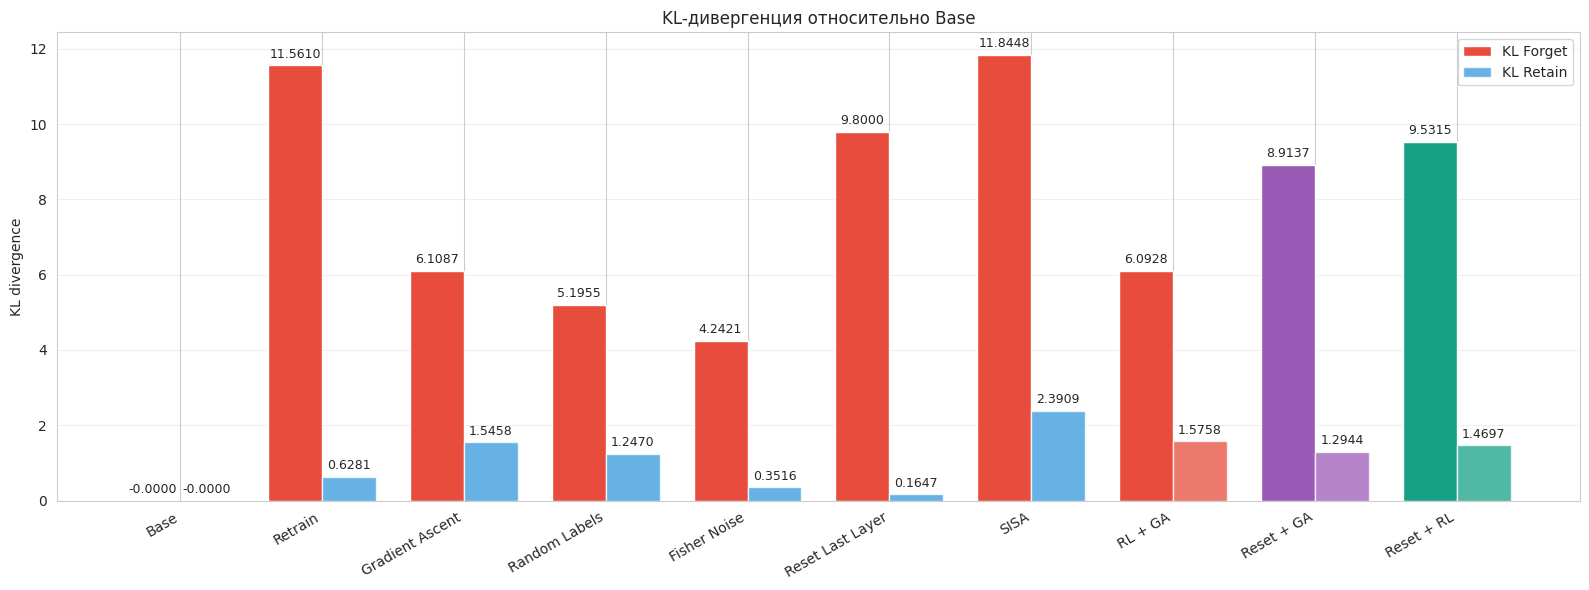

In [21]:
kl_plot = _ordered_df(kl_df)
methods = kl_plot["Method"].astype(str).tolist()
x = np.arange(len(methods))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 6))

colors_forget = [
    HYBRID_COLORS.get(m, "#e74c3c") if m in HYBRID_METHODS else "#e74c3c"
    for m in methods
]
colors_retain = [
    HYBRID_COLORS.get(m, "#3498db") if m in HYBRID_METHODS else "#3498db"
    for m in methods
]

b1 = ax.bar(x - width / 2, kl_plot["KL Forget"], width, label="KL Forget", color=colors_forget, edgecolor="white")
b2 = ax.bar(x + width / 2, kl_plot["KL Retain"], width, label="KL Retain", color=colors_retain, edgecolor="white", alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel("KL divergence")
ax.set_title("KL-дивергенция относительно Base")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
_annotate_bars(ax, b1, fmt="{:.4f}")
_annotate_bars(ax, b2, fmt="{:.4f}")
plt.tight_layout()
plt.show()

###22. Анализ Truth Ratio

In [22]:
truth_df = pd.DataFrame(truth_ratio_results)

truth_df

,Method,Retain Truth,Forget Truth
0,Base,0.743294,6.489184e-01
1,Retrain,0.640195,2.751466e-11
2,Gradient Ascent,0.477583,1.861704e-02
3,Random Labels,0.510938,2.914421e-02
4,Fisher Noise,0.670621,5.956906e-03
5,Reset Last Layer,0.708557,2.988417e-07
6,SISA,0.097224,3.134733e-09
7,RL + GA,0.469755,1.312009e-02
8,Reset + GA,0.483219,5.887582e-06
9,Reset + RL,0.458902,3.348862e-06


###23. График Truth Ratio

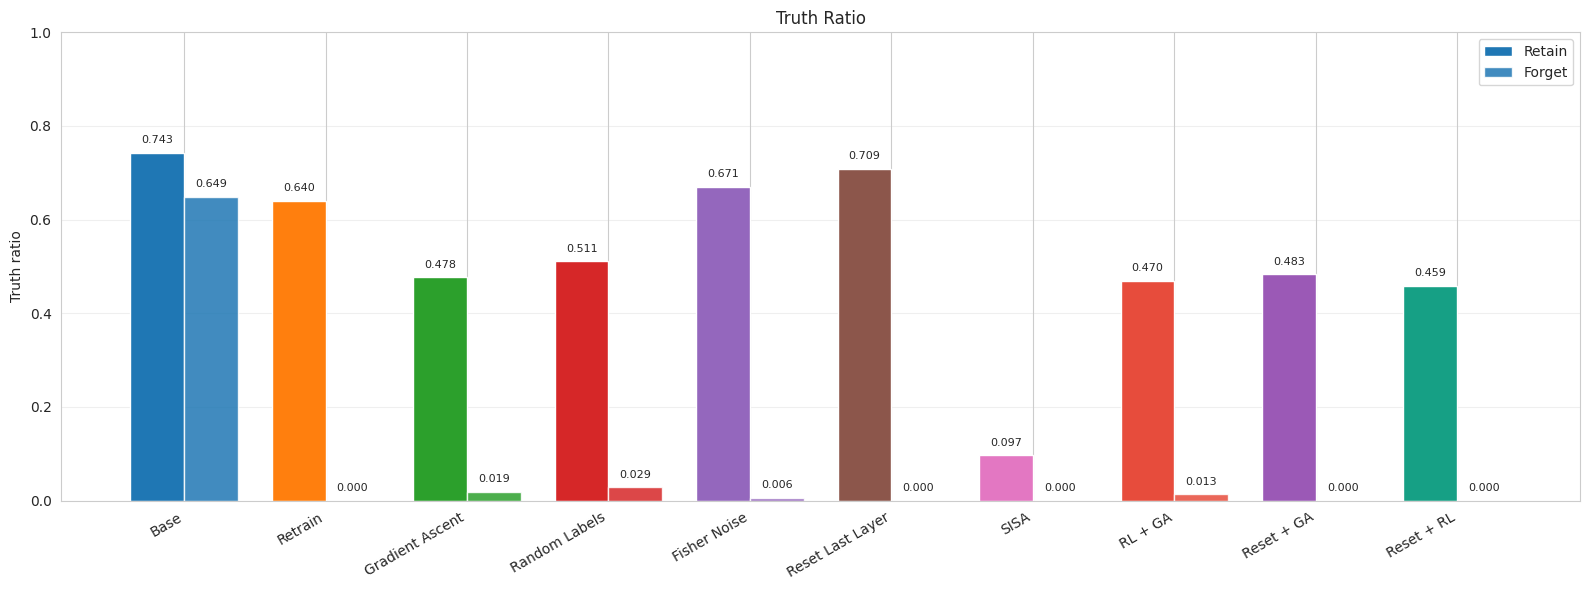

In [23]:
truth_plot = _ordered_df(truth_df)
methods = truth_plot["Method"].astype(str).tolist()
x = np.arange(len(methods))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 6))

bar_colors_r = [METHOD_COLORS.get(m, "#2ecc71") for m in methods]
bar_colors_f = [METHOD_COLORS.get(m, "#e67e22") for m in methods]

ax.bar(x - width / 2, truth_plot["Retain Truth"], width, label="Retain", color=bar_colors_r, edgecolor="white")
ax.bar(x + width / 2, truth_plot["Forget Truth"], width, label="Forget", color=bar_colors_f, edgecolor="white", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Truth ratio")
ax.set_title("Truth Ratio")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

for i in range(len(methods)):
    ax.text(x[i] - width/2, truth_plot["Retain Truth"].iloc[i] + 0.02, f"{truth_plot['Retain Truth'].iloc[i]:.3f}", ha="center", fontsize=8)
    ax.text(x[i] + width/2, truth_plot["Forget Truth"].iloc[i] + 0.02, f"{truth_plot['Forget Truth'].iloc[i]:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

###24. MIA (Membership Inference Attack)

In [24]:
mia_df

,Method,MIA AUC
0,Base,0.449271
1,Retrain,0.317491
2,Gradient Ascent,0.186720
3,Random Labels,0.178909
4,Fisher Noise,0.264157
5,Reset Last Layer,0.300239
6,SISA,0.306289
7,RL + GA,0.178438
8,Reset + GA,0.160453
9,Reset + RL,0.135356


###25. График MIA атак

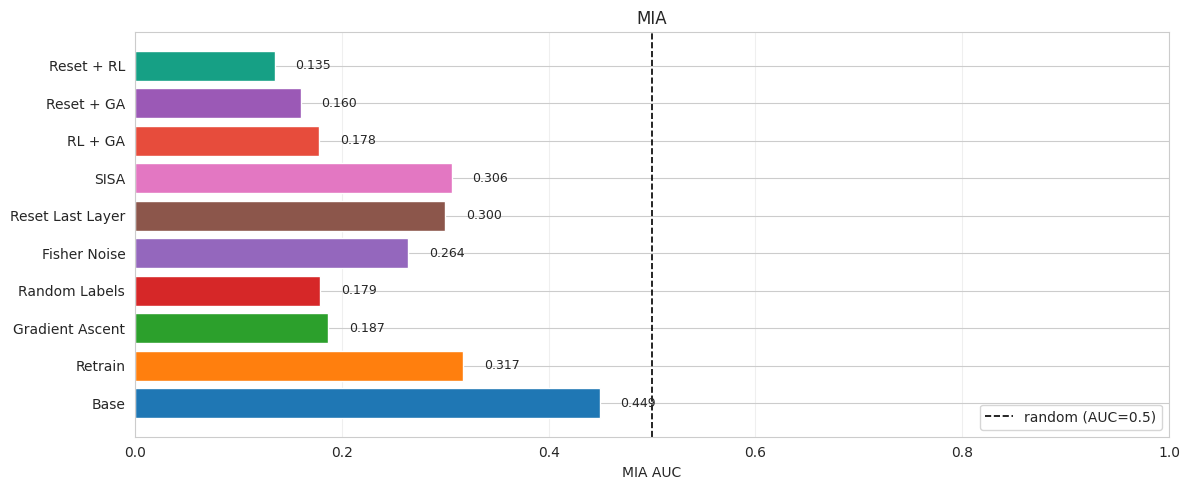

In [25]:
mia_plot = _ordered_df(mia_df)
methods = mia_plot["Method"].astype(str).tolist()
values = mia_plot["MIA AUC"].values
colors = [METHOD_COLORS.get(m, "gray") for m in methods]

fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(methods))))
bars = ax.barh(methods, values, color=colors, edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="random (AUC=0.5)")
ax.set_xlim(0, 1)
ax.set_xlabel("MIA AUC")
ax.set_title("MIA")
for bar, val in zip(bars, values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

###26. Анализ и график времени выполнения

,Method,Runtime
9,Base,NaN
0,Retrain,963.098120
8,Gradient Ascent,121.756763
7,Random Labels,1.312148
3,Fisher Noise,95.700090
2,Reset Last Layer,129.059937
1,SISA,188.336293
6,RL + GA,2.395624
5,Reset + GA,79.193757
4,Reset + RL,79.102949


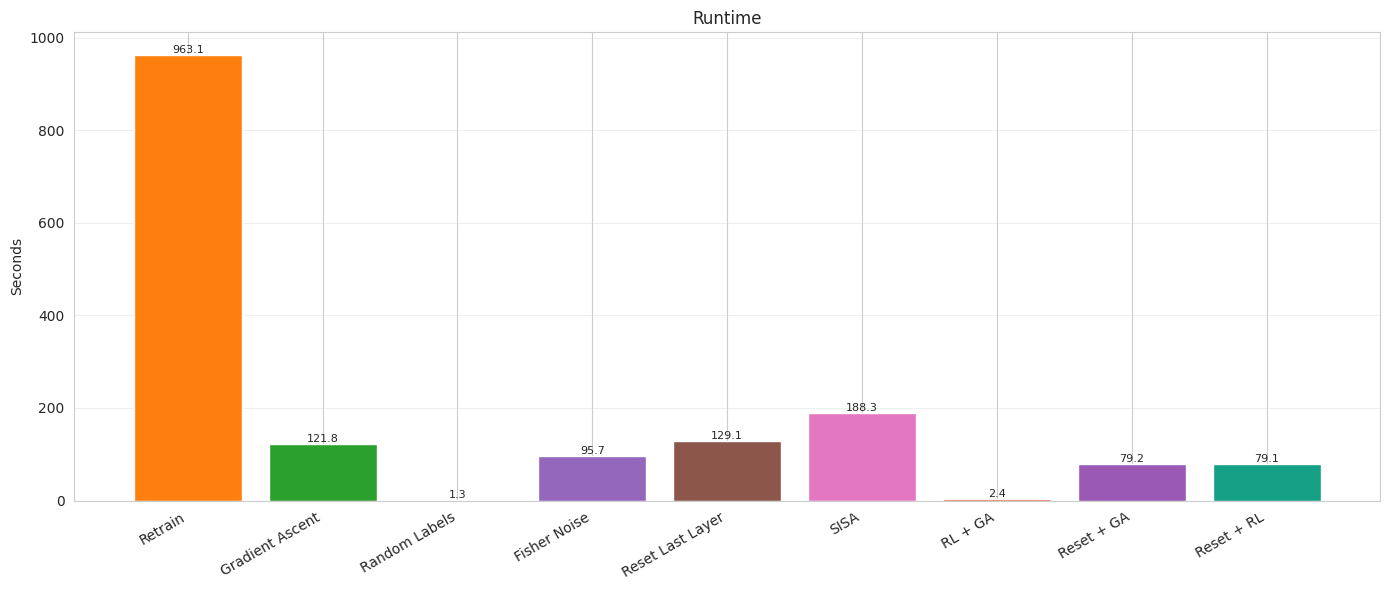

In [26]:
runtime_df = _ordered_df(results_df)[["Method", "Runtime"]]
display(runtime_df)

fig, ax = plt.subplots(figsize=(14, 6))
methods = runtime_df["Method"].astype(str).tolist()
vals = runtime_df["Runtime"].values
bars = ax.bar(methods, vals, color=[METHOD_COLORS.get(m, "gray") for m in methods], edgecolor="white")
ax.set_ylabel("Seconds")
ax.set_title("Runtime")
plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
for bar in bars:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

###27. Таблица финальных результатов

In [27]:
final_table = (
    results_df
    .merge(kl_df, on="Method", how="left")
    .merge(truth_df, on="Method", how="left")
    .merge(mia_df, on="Method", how="left")
)

final_cols = [
    "Method",

    "Retain Acc",
    "Forget Acc",
    "Test Acc",

    "Retain Loss",
    "Forget Loss",
    "Test Loss",

    "KL Forget",
    "KL Retain",

    "Retain Truth",
    "Forget Truth",

    "MIA AUC",
    "Runtime",
]

final_table = final_table[[c for c in final_cols if c in final_table.columns]]
final_table = _ordered_df(final_table)

final_table.to_csv("final_research_results.csv", index=False)
hybrid_final = final_table[final_table["Method"].isin(HYBRID_METHODS)].copy()
hybrid_final.to_csv("hybrid_unlearning_results.csv", index=False)

final_table

,Method,Retain Acc,Forget Acc,Test Acc,Retain Loss,Forget Loss,Test Loss,KL Forget,KL Retain,Retain Truth,Forget Truth,MIA AUC,Runtime
9,Base,0.856393,0.786458,0.538117,0.491639,0.769764,2.063164,-7.235865e-07,-7.491932e-07,0.743294,6.489184e-01,0.449271,NaN
0,Retrain,0.762711,0.000000,0.522791,0.783469,28.177471,2.247140,1.156099e+01,6.280761e-01,0.640195,2.751466e-11,0.317491,963.098120
8,Gradient Ascent,0.525063,0.036458,0.389630,2.071899,8.514158,3.648553,6.108676e+00,1.545782e+00,0.477583,1.861704e-02,0.186720,121.756763
7,Random Labels,0.568329,0.021484,0.408539,1.763185,7.493718,3.394520,5.195523e+00,1.247035e+00,0.510938,2.914421e-02,0.178909,1.312148
3,Fisher Noise,0.774211,0.000000,0.505175,0.725816,7.703920,2.370248,4.242062e+00,3.516007e-01,0.670621,5.956906e-03,0.264157,95.700090
2,Reset Last Layer,0.818530,0.000000,0.523089,0.585578,17.770629,2.252788,9.800020e+00,1.646738e-01,0.708557,2.988417e-07,0.300239,129.059937
1,SISA,0.250157,0.000000,0.254678,3.045285,20.391695,3.195090,1.184477e+01,2.390876e+00,0.097224,3.134733e-09,0.306289,188.336293
6,RL + GA,0.521117,0.011719,0.384853,2.075331,8.913439,3.682935,6.092774e+00,1.575834e+00,0.469755,1.312009e-02,0.178438,2.395624
5,Reset + GA,0.543109,0.000000,0.409335,1.819743,13.050113,3.209874,8.913685e+00,1.294437e+00,0.483219,5.887582e-06,0.160453,79.193757
4,Reset + RL,0.514908,0.000000,0.394805,2.027106,13.754608,3.386640,9.531531e+00,1.469712e+00,0.458902,3.348862e-06,0.135356,79.102949


###28. Распределение уверенности на Forget Set

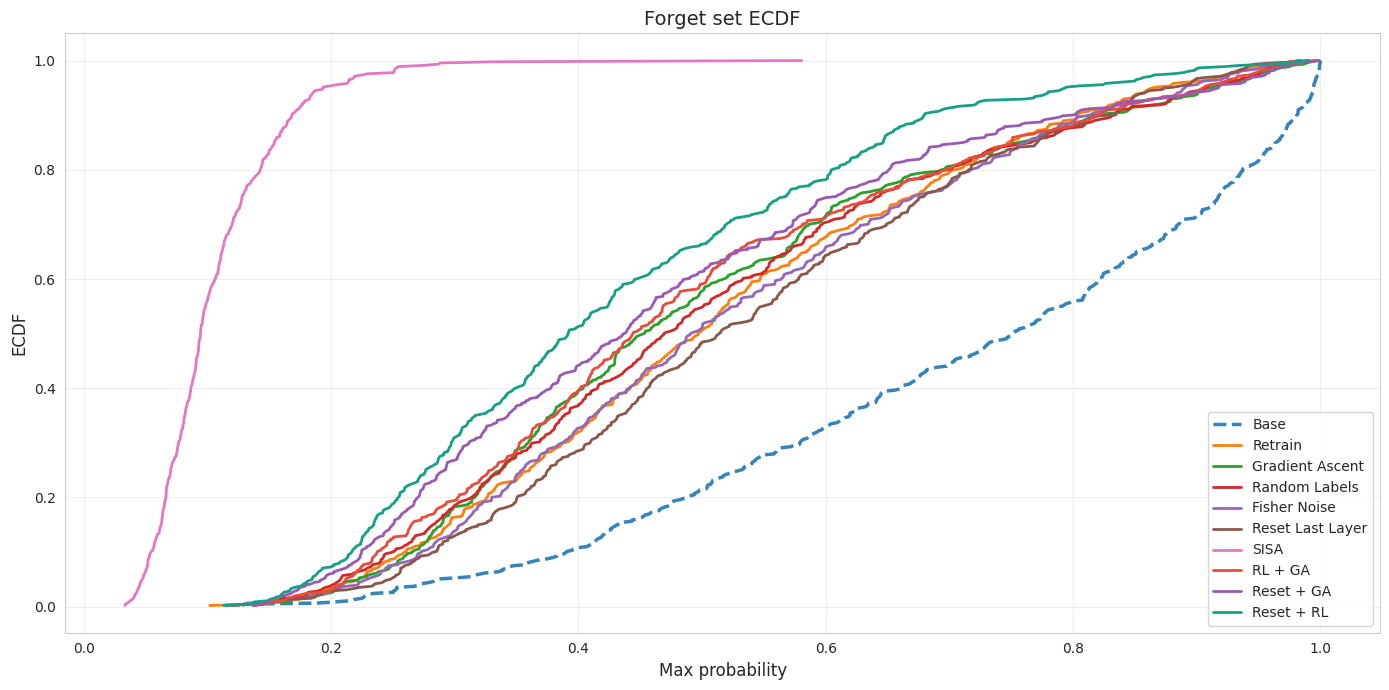

In [28]:
def load_method_model(method_name):
    m = load_model_from_stash(method_name)
    if not isinstance(m, SISAEnsemble):
        m = m.to(DEVICE)
    m.eval()
    return m


def confidence_distribution(model, loader):
    model.eval()
    confidences = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)

            probs = _forward_probs(model, images)

            confidences.extend(
                probs.max(dim=1)[0].detach().cpu().numpy()
            )

    return np.asarray(confidences)


def confidence_from_stash(method_name, loader):
    m = load_method_model(method_name)

    try:
        return confidence_distribution(m, loader)

    finally:
        del m
        cuda_cleanup()


ALL_METHODS = [
    "Base",
    "Retrain",
    "Gradient Ascent",
    "Random Labels",
    "Fisher Noise",
    "Reset Last Layer",
    "SISA",
    "RL + GA",
    "Reset + GA",
    "Reset + RL",
]


ALL_METHODS = [m for m in ALL_METHODS if m in MODEL_CPU]

if "Base" not in MODEL_CPU:
    raise ValueError("Нет Base в MODEL_CPU. Выполните ###7–###10.")



fig, ax = plt.subplots(figsize=(14, 7))

for method_name in ALL_METHODS:

    conf = np.sort(
        confidence_from_stash(method_name, forget_loader)
    )

    y = np.arange(1, len(conf) + 1) / len(conf)

    # стиль для Base
    if method_name == "Base":
        linestyle = "--"
        linewidth = 2.5
        alpha = 0.9
    else:
        linestyle = "-"
        linewidth = 2
        alpha = 1.0

    ax.plot(
        conf,
        y,
        label=method_name,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=alpha,
        color=METHOD_COLORS.get(
            method_name,
            None
        ),
    )

ax.set_xlabel("Max probability", fontsize=12)
ax.set_ylabel("ECDF", fontsize=12)

ax.set_title(
    "Forget set ECDF",
    fontsize=14
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=10,
    loc="lower right"
)

plt.tight_layout()
plt.show()

###29. Визуализация забывания

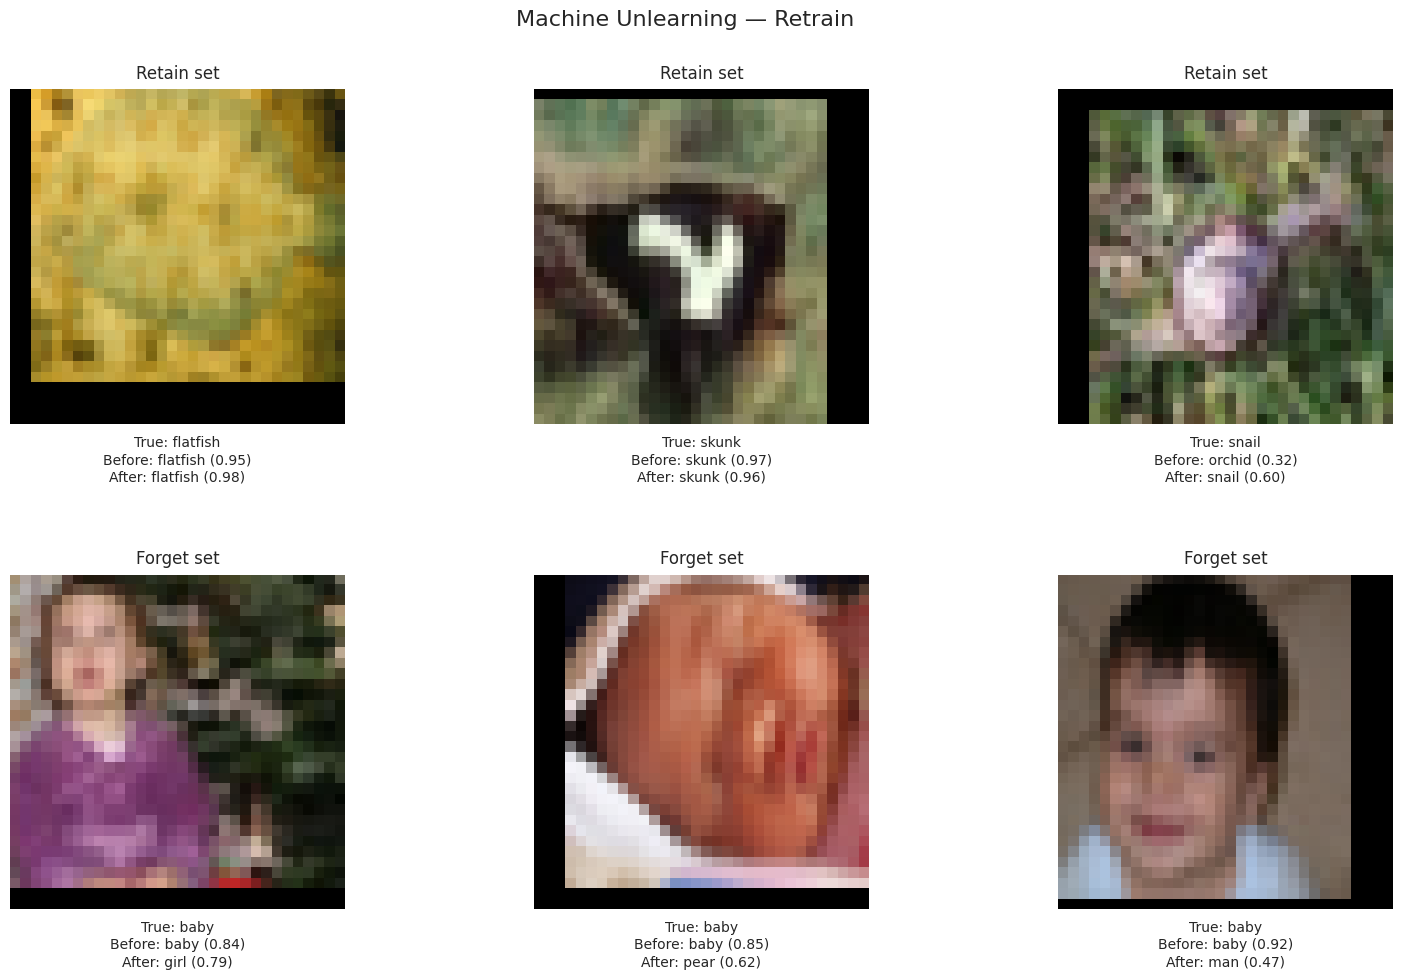

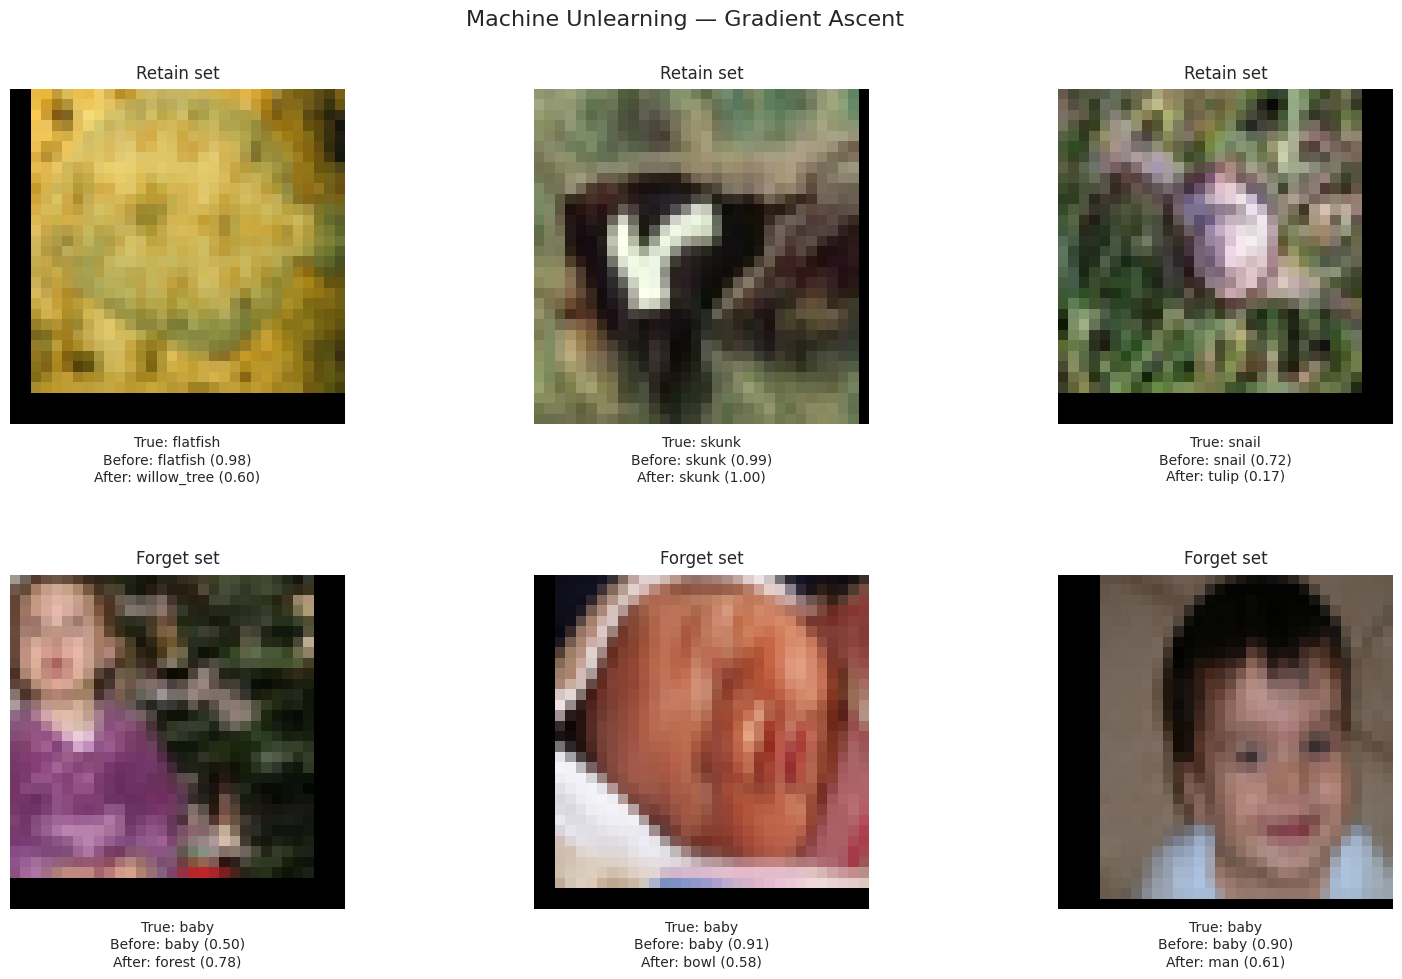

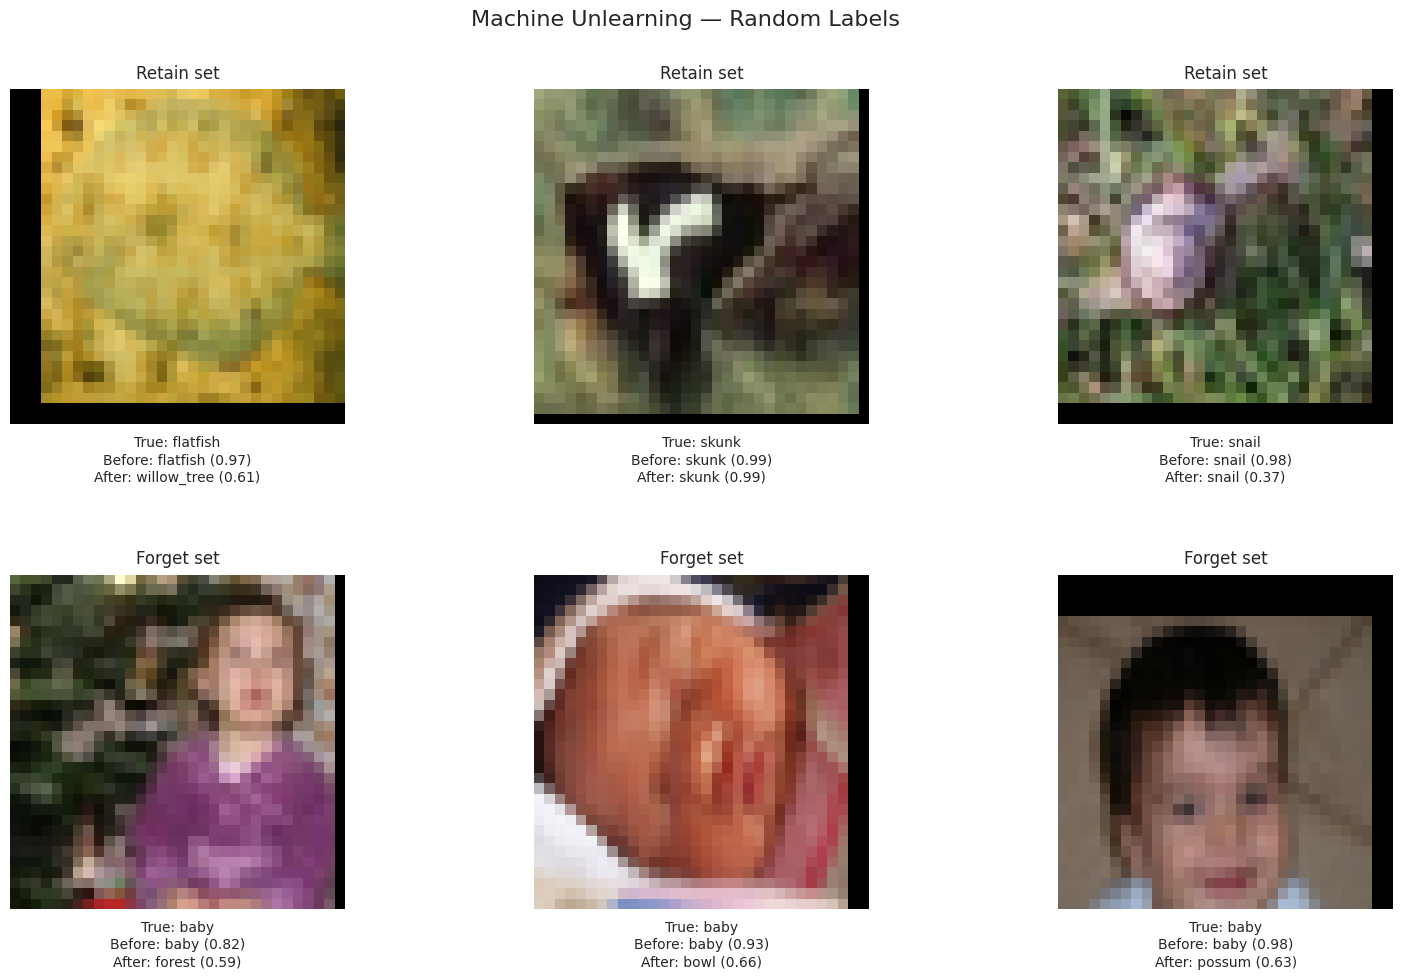

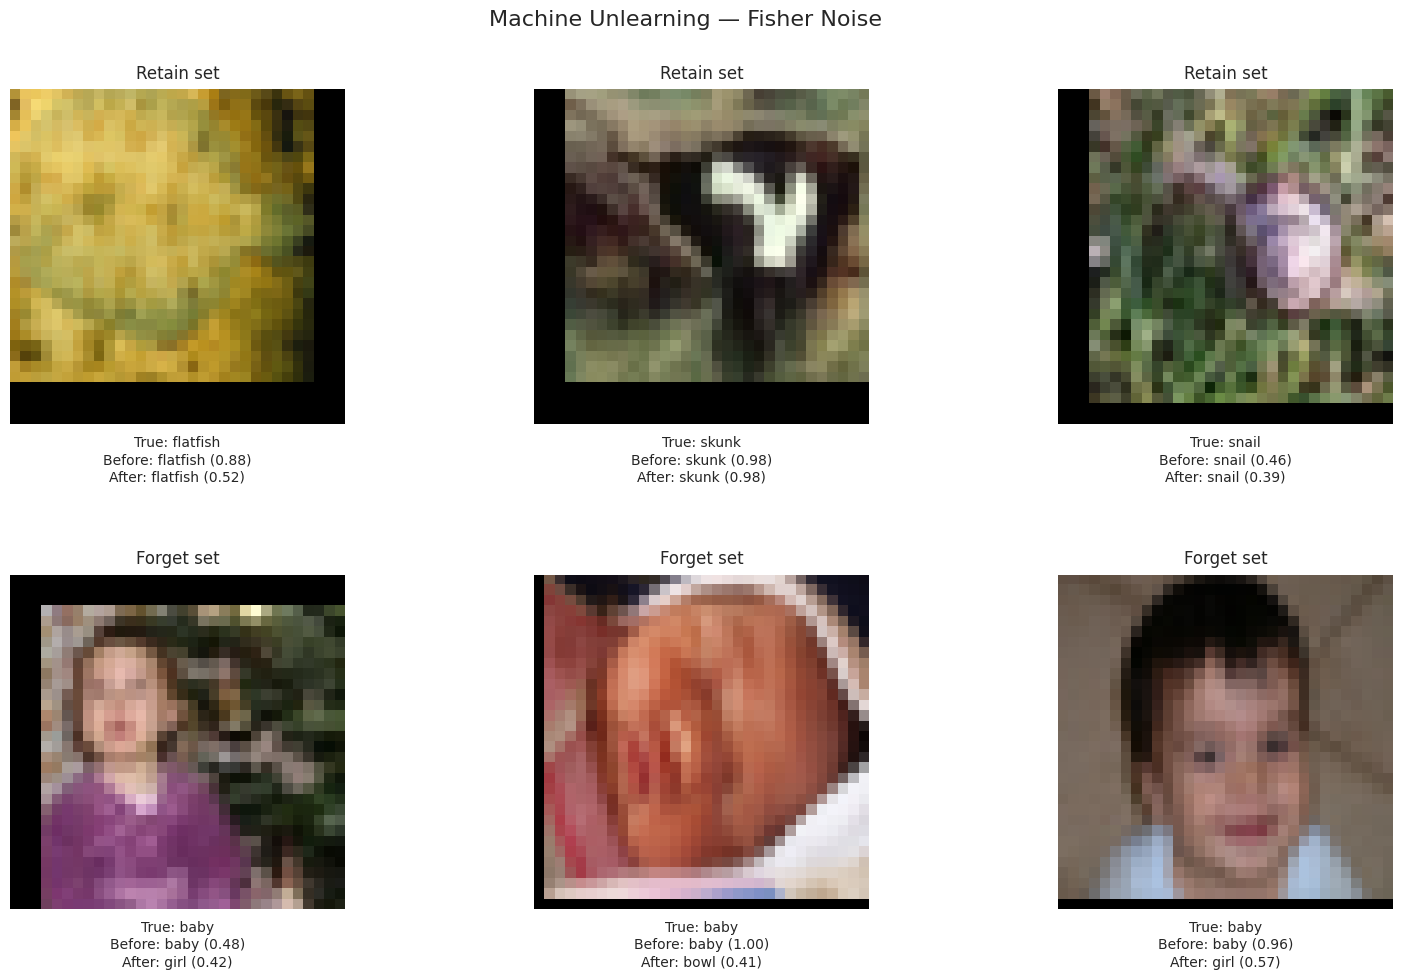

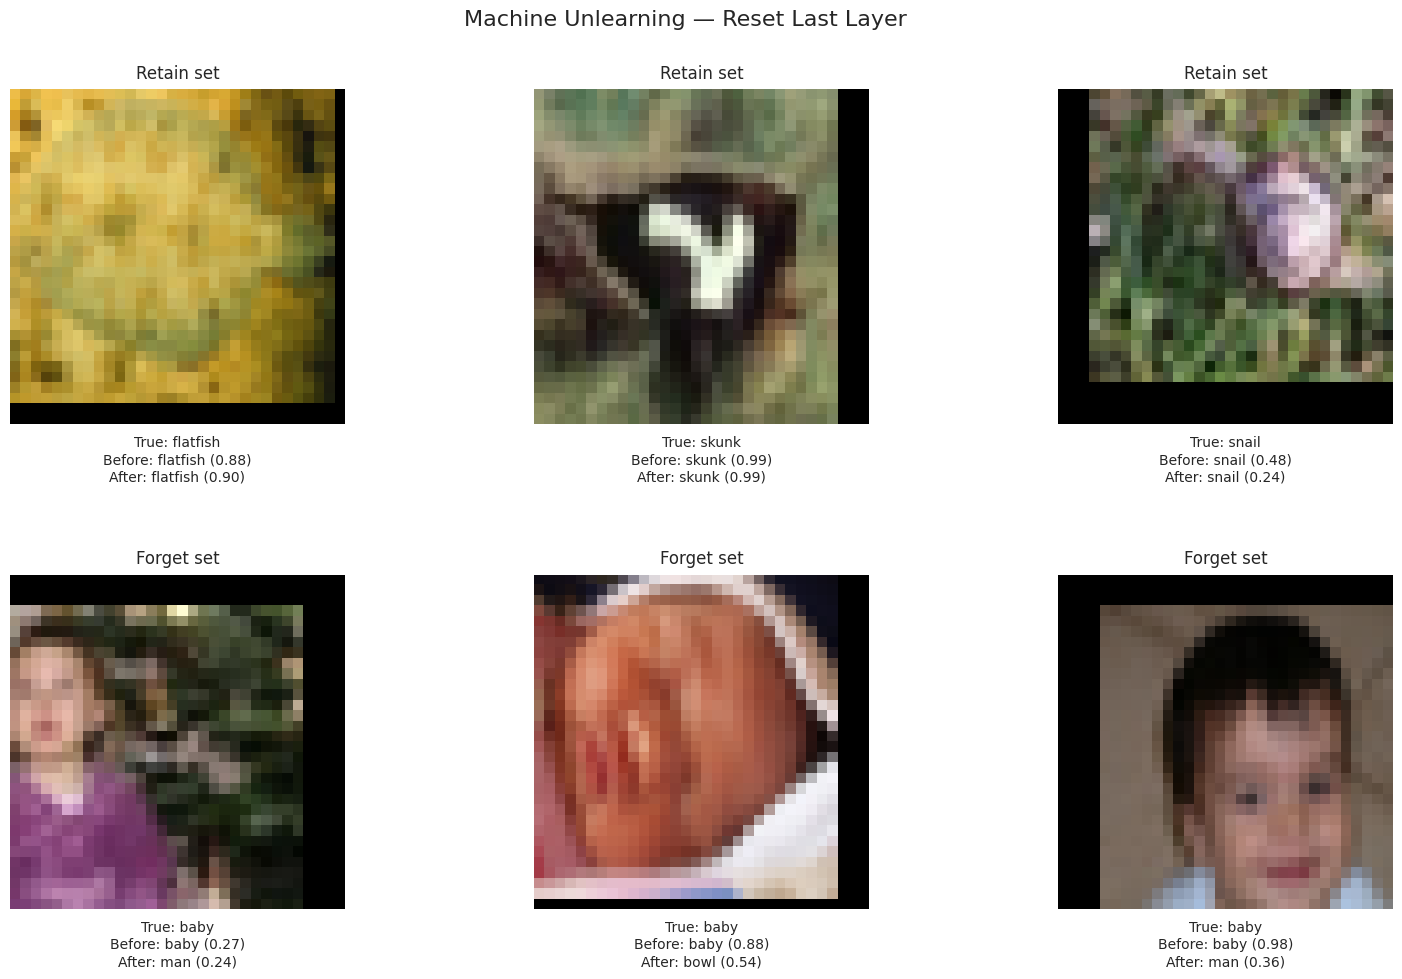

Пропуск SISA: SISA не загружается через state_dict stash


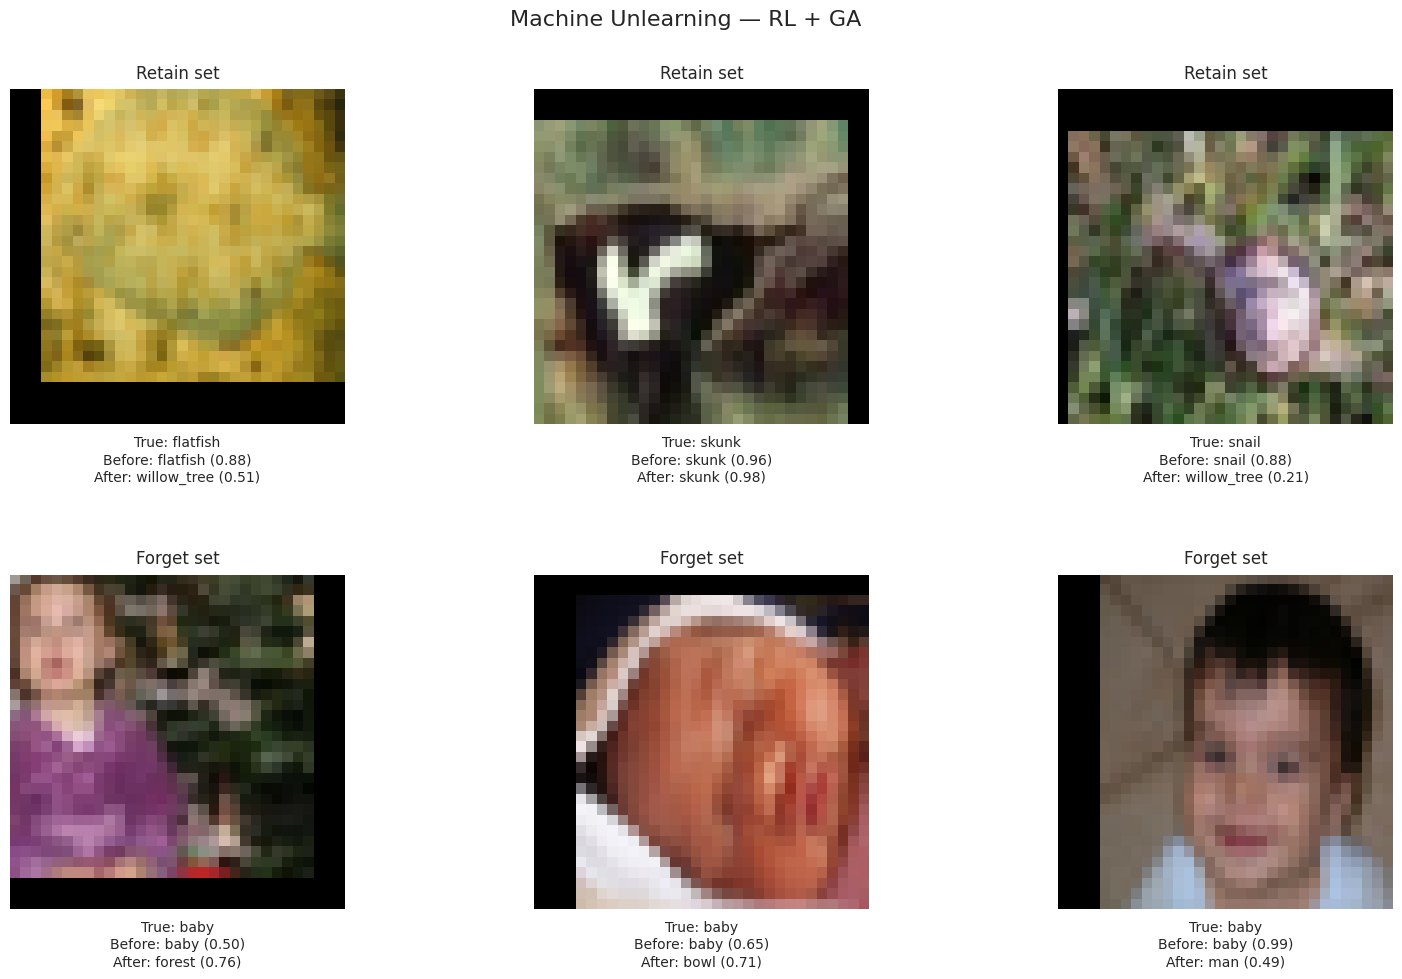

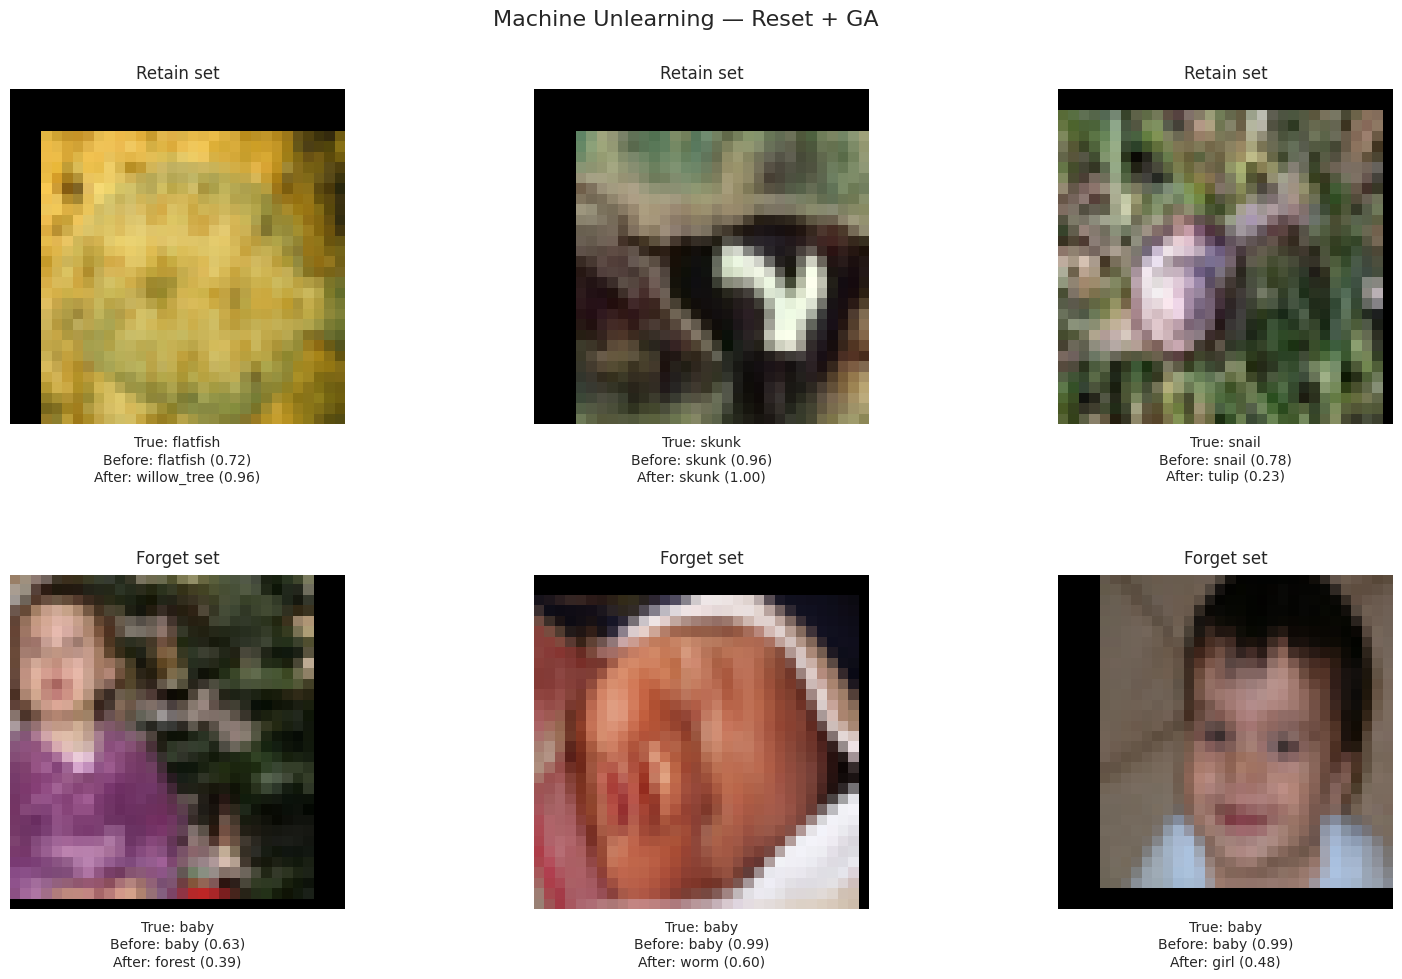

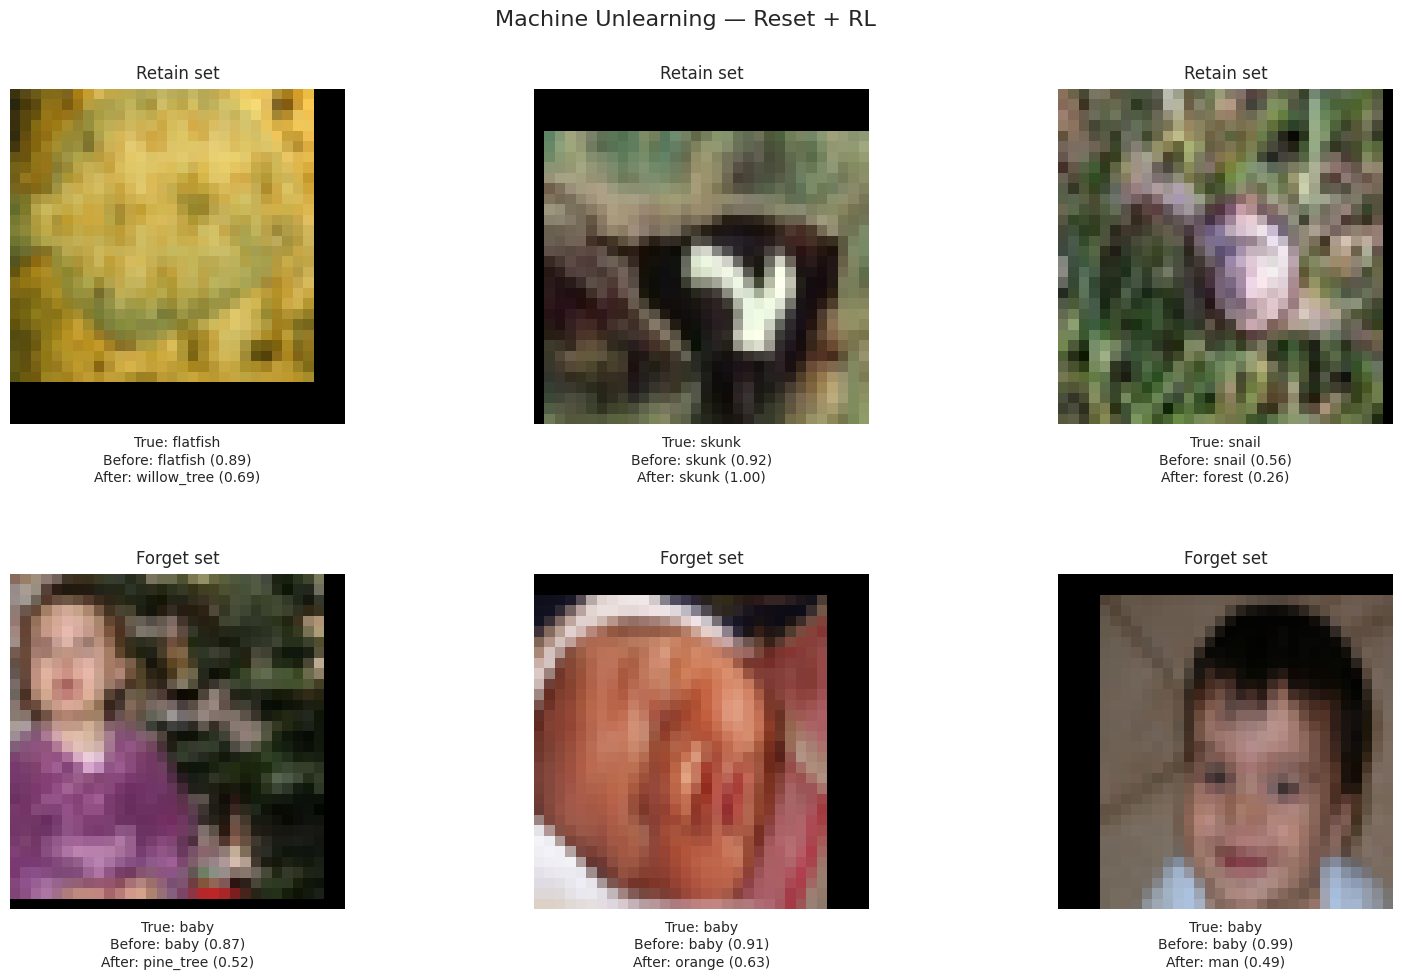

In [29]:
def load_method_model(method_name):
    m = load_model_from_stash(method_name)

    if not isinstance(m, SISAEnsemble):
        m = m.to(DEVICE)

    m.eval()
    return m


def visualize_unlearning_effect(
    original_model,
    unlearned_model,
    retain_dataset,
    forget_dataset,
    method_name="Unlearned",
    class_names_list=None,
):
    original_model = original_model.to(DEVICE).eval()
    unlearned_model = unlearned_model.to(DEVICE).eval()

    names = class_names_list if class_names_list is not None else class_names

    ds_mean = np.array(
        DATASET_REGISTRY[cfg.dataset_name]["mean"],
        dtype=np.float32,
    )

    ds_std = np.array(
        DATASET_REGISTRY[cfg.dataset_name]["std"],
        dtype=np.float32,
    )


    def select_diverse_samples(dataset, n_samples=3):
        selected = []
        used_classes = set()


        for idx in range(len(dataset)):
            _, label = dataset[idx]

            if isinstance(label, torch.Tensor):
                label = int(label.item())

            if label not in used_classes:
                selected.append(idx)
                used_classes.add(label)

            if len(selected) >= n_samples:
                break

        if len(selected) < n_samples:
            for idx in range(len(dataset)):
                if idx not in selected:
                    selected.append(idx)

                if len(selected) >= n_samples:
                    break

        return selected[:n_samples]

    retain_indices = select_diverse_samples(retain_dataset, 3)
    forget_indices = select_diverse_samples(forget_dataset, 3)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    def _probs(model, x):
        return _forward_probs(model, x)

    def _to_image_np(tensor):
        img = tensor.detach().cpu().permute(1, 2, 0).numpy()

        return np.clip(
            img * ds_std + ds_mean,
            0.0,
            1.0,
        )

    def _label_name(label):
        if isinstance(label, torch.Tensor):
            label = label.item()

        return names[int(label)]


    with torch.no_grad():

        for plot_idx, ds_idx in enumerate(retain_indices):

            ax = axes[plot_idx]

            image, label = retain_dataset[ds_idx]

            x = image.unsqueeze(0).to(DEVICE)

            orig_probs = _probs(original_model, x)
            unl_probs = _probs(unlearned_model, x)

            orig_pred = int(orig_probs.argmax(dim=1).item())
            orig_conf = float(orig_probs.max().item())

            unl_pred = int(unl_probs.argmax(dim=1).item())
            unl_conf = float(unl_probs.max().item())

            ax.imshow(
                _to_image_np(image),
                interpolation="nearest",
            )

            ax.set_title(
                "Retain set",
                fontsize=12,
                pad=8,
            )

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.set_xlabel(
                f"True: {_label_name(label)}\n"
                f"Before: {names[orig_pred]} ({orig_conf:.2f})\n"
                f"After: {names[unl_pred]} ({unl_conf:.2f})",
                fontsize=10,
                labelpad=8,
                linespacing=1.3,
            )

        for local_idx, ds_idx in enumerate(forget_indices):

            plot_idx = local_idx + 3

            ax = axes[plot_idx]

            image, label = forget_dataset[ds_idx]

            x = image.unsqueeze(0).to(DEVICE)

            orig_probs = _probs(original_model, x)
            unl_probs = _probs(unlearned_model, x)

            orig_pred = int(orig_probs.argmax(dim=1).item())
            orig_conf = float(orig_probs.max().item())

            unl_pred = int(unl_probs.argmax(dim=1).item())
            unl_conf = float(unl_probs.max().item())

            ax.imshow(
                _to_image_np(image),
                interpolation="nearest",
            )

            ax.set_title(
                "Forget set",
                fontsize=12,
                pad=8,
            )

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.set_xlabel(
                f"True: {_label_name(label)}\n"
                f"Before: {names[orig_pred]} ({orig_conf:.2f})\n"
                f"After: {names[unl_pred]} ({unl_conf:.2f})",
                fontsize=10,
                labelpad=8,
                linespacing=1.3,
            )

    fig.suptitle(
        f"Machine Unlearning — {method_name}",
        fontsize=16,
        y=0.98,
    )

    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        top=0.90,
        bottom=0.08,
        wspace=0.15,
        hspace=0.45,
    )

    plt.show()


def visualize_stashed_pair(
    base_name,
    unlearn_name,
    retain_dataset,
    forget_dataset,
):
    if base_name not in MODEL_CPU or unlearn_name not in MODEL_CPU:
        print(f"Пропуск {unlearn_name}: нет в MODEL_CPU")
        return

    if unlearn_name == "SISA" or base_name == "SISA":
        print(f"Пропуск {unlearn_name}: SISA не загружается через state_dict stash")
        return

    base_m = load_method_model(base_name)
    unl_m = load_method_model(unlearn_name)

    try:
        visualize_unlearning_effect(
            base_m,
            unl_m,
            retain_dataset,
            forget_dataset,
            method_name=unlearn_name,
        )

    finally:
        del base_m, unl_m
        cuda_cleanup()




for name in [
    "Retrain",
    "Gradient Ascent",
    "Random Labels",
    "Fisher Noise",
    "Reset Last Layer",
    "SISA",
]:
    visualize_stashed_pair(
        "Base",
        name,
        retain_dataset,
        forget_dataset,
    )


HYBRID_ORDER = [
    "RL + GA",
    "Reset + GA",
    "Reset + RL",
]

# --- гибриды ---
for name in HYBRID_ORDER:
    visualize_stashed_pair(
        "Base",
        name,
        retain_dataset,
        forget_dataset,
    )

###30. Загрузка пользовательских изображений

In [ ]:
from google.colab import files
import zipfile
import shutil
import os

UPLOAD_DIR = "./custom_test"


if os.path.exists(UPLOAD_DIR):
    shutil.rmtree(UPLOAD_DIR)

os.makedirs(UPLOAD_DIR, exist_ok=True)

print("Загрузите ZIP-архив с изображениями")

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(UPLOAD_DIR)



items = os.listdir(UPLOAD_DIR)

if len(items) == 1:

    possible_root = os.path.join(
        UPLOAD_DIR,
        items[0]
    )

    if os.path.isdir(possible_root):

        UPLOAD_DIR = possible_root

print(f"Dataset root: {UPLOAD_DIR}")
print("Classes found:")

for item in os.listdir(UPLOAD_DIR):
    print("-", item)

Загрузите ZIP-архив с изображениями


###31. Датасет пользовательских изображений

In [ ]:
from PIL import Image

CUSTOM_CLASSES = class_names

class CustomImageDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.samples = []
        self.transform = transform

        for class_name in sorted(os.listdir(root_dir)):

            class_path = os.path.join(root_dir, class_name)

            if not os.path.isdir(class_path):
                continue

            if class_name not in CUSTOM_CLASSES:
                print(f"Пропуск неизвестного класса: {class_name}")
                continue

            label = CUSTOM_CLASSES.index(class_name)

            for fname in sorted(os.listdir(class_path)):

                if fname.lower().endswith(
                    (".png", ".jpg", ".jpeg", ".bmp")
                ):

                    path = os.path.join(class_path, fname)

                    self.samples.append(
                        (path, label)
                    )

        print(f"Найдено изображений: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")

        image = image.resize(
            (cfg.image_size, cfg.image_size)
        )

        if self.transform:
            image = self.transform(image)

        return image, label, path

###32. Загрузка пользовательского датасета

In [ ]:
custom_dataset = CustomImageDataset(
    root_dir=UPLOAD_DIR,
    transform=valid_transform
)

custom_loader = DataLoader(
    custom_dataset,
    batch_size=1,
    shuffle=False
)

print("Custom samples:", len(custom_dataset))

###33. Визуализация результатов классификации

In [ ]:
def visualize_custom_predictions_split(
    base_model,
    unlearn_model,
    loader,
    method_name="Unlearning",
    seed=42,
):

    random.seed(seed)
    np.random.seed(seed)

    base_model.eval()
    unlearn_model.eval()

    ds_mean = np.array(DATASET_REGISTRY[cfg.dataset_name]["mean"], dtype=np.float32)
    ds_std = np.array(DATASET_REGISTRY[cfg.dataset_name]["std"], dtype=np.float32)

    forget_class_ids = set(cfg.forget_classes)

    samples = []

    with torch.no_grad():
        for images, labels, paths in loader:

            images = images.to(DEVICE)

            base_probs = _forward_probs(base_model, images)
            unlearn_probs = _forward_probs(unlearn_model, images)

            base_top2_conf, base_top2_pred = torch.topk(base_probs, k=2, dim=1)
            un_top2_conf, un_top2_pred = torch.topk(unlearn_probs, k=2, dim=1)

            lbl = int(labels[0].item() if torch.is_tensor(labels[0]) else labels[0])

            samples.append({
                "image": images[0].cpu(),
                "label": lbl,
                "path": paths[0],

                "base_pred": base_top2_pred[0].cpu().numpy(),
                "base_conf": base_top2_conf[0].cpu().numpy(),

                "un_pred": un_top2_pred[0].cpu().numpy(),
                "un_conf": un_top2_conf[0].cpu().numpy(),
            })

    if len(samples) == 0:
        print("Нет изображений")
        return

    retain_pool = {}
    forget_pool = {}

    for s in samples:
        cls = s["label"]

        if cls in forget_class_ids:
            forget_pool.setdefault(cls, []).append(s)
        else:
            retain_pool.setdefault(cls, []).append(s)


    def sample_pool(pool, n=3):
        all_items = []
        for cls, items in pool.items():
            all_items.extend(items)

        random.shuffle(all_items)

        chosen = []
        used_classes = set()
        used_paths = set()

        for s in all_items:
            cls = s["label"]
            path = s["path"]

            if len(chosen) >= n:
                break

            if cls not in used_classes and path not in used_paths:
                chosen.append(s)
                used_classes.add(cls)
                used_paths.add(path)

        for s in all_items:
            if len(chosen) >= n:
                break
            if s["path"] not in used_paths:
                chosen.append(s)
                used_paths.add(s["path"])

        return chosen

    retain_samples = sample_pool(retain_pool, 3)
    forget_samples = sample_pool(forget_pool, 3)


    def to_img(t):
        img = t.permute(1, 2, 0).numpy()
        return np.clip(img * ds_std + ds_mean, 0, 1)


    def render(ax, sample, color):

        ax.imshow(to_img(sample["image"]))
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(6)
            spine.set_color(color)

        true_name = class_names[sample["label"]]

        b1 = class_names[sample["base_pred"][0]]
        b2 = class_names[sample["base_pred"][1]]
        b1c = sample["base_conf"][0]
        b2c = sample["base_conf"][1]

        a1 = class_names[sample["un_pred"][0]]
        a2 = class_names[sample["un_pred"][1]]
        a1c = sample["un_conf"][0]
        a2c = sample["un_conf"][1]

        ax.set_xlabel(
            f"True: {true_name}\n\n"
            f"Before:\n"
            f"1. {b1} ({b1c:.2f})\n"
            f"2. {b2} ({b2c:.2f})\n\n"
            f"After:\n"
            f"1. {a1} ({a1c:.2f})\n"
            f"2. {a2} ({a2c:.2f})",
            fontsize=10,
            labelpad=10,
            linespacing=1.3,
        )


    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i in range(3):
        render(axes[i], retain_samples[i], "#2ecc71")
        axes[i].set_title("Retain set", fontsize=13, weight="bold")

    for i in range(3):
        render(axes[i + 3], forget_samples[i], "#e74c3c")
        axes[i + 3].set_title("Forget set", fontsize=13, weight="bold")

    fig.suptitle(
        f"Machine Unlearning — {method_name}",
        fontsize=20,
        weight="bold",
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

###34. Демонстрация работы unlearning

In [ ]:
base_model = load_method_model("Base")
unlearn_model = load_method_model("Random Labels")

visualize_custom_predictions_split(
    base_model,
    unlearn_model,
    custom_loader,
    method_name="Random Labels",
    seed=42
)

del base_model
del unlearn_model
cuda_cleanup()